In [103]:
import pandas as pd

df = pd.read_csv(
    "../twcs.csv",
    usecols=[
        "tweet_id",
        "author_id",
        "inbound",
        "created_at",
        "text",
        "response_tweet_id",
        "in_response_to_tweet_id",
    ]
)

df.head()


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [104]:
df.shape

(2811774, 7)

In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2811774 entries, 0 to 2811773
Data columns (total 7 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   tweet_id                 int64  
 1   author_id                str    
 2   inbound                  bool   
 3   created_at               str    
 4   text                     str    
 5   response_tweet_id        str    
 6   in_response_to_tweet_id  float64
dtypes: bool(1), float64(1), int64(1), str(4)
memory usage: 131.4 MB


In [106]:
df.isna().sum()

tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64

In [107]:
df["inbound"].value_counts()

inbound
True     1537843
False    1273931
Name: count, dtype: int64

In [108]:
verizon = df[df["author_id"] == "VerizonSupport"].copy()

verizon.shape

(17966, 7)

In [109]:
verizon_tweet_ids = set(verizon["tweet_id"])

customer_messages = df[
    (df["inbound"] == True) &
    (df["in_response_to_tweet_id"].isin(verizon_tweet_ids))
].copy()

customer_messages.shape

(12953, 7)

In [110]:
customer_messages[["tweet_id", "author_id", "text", "in_response_to_tweet_id"]].head(20)

,tweet_id,author_id,text,in_response_to_tweet_id
29,35,115719,"@VerizonSupport I finally got someone that helped me, thanks!",34.0
35,41,115721,@VerizonSupport What else can I provide? They refuse to help me because they cannot validate the account...,40.0
37,44,115721,"@VerizonSupport How? I have my phone number and email, that's it. How did I get equipment and service? I'm literally trying to pay and nobody can find me?",43.0
45,51,115723,"@VerizonSupport Don’t know, router is downstairs. But it’s just the WiFi Nothing connected to Ethernet",52.0
47,53,115723,@VerizonSupport Just randomly boots me offline there it goes again,54.0
49,55,115723,@VerizonSupport Yep,56.0
51,57,115723,@VerizonSupport Cuts out every 20 minutes this is ridiculous,58.0
853,1423,115988,@VerizonSupport no! it just says amount due $27.04,1422.0
1515,2217,116210,@VerizonSupport Banking. https://t.co/8535p04F9S,2218.0
1519,2221,116211,@VerizonSupport I’m standing in front of it,2220.0


In [111]:
customer_id = 115723

conversation = df[df["author_id"].astype(str) == str(customer_id)][
    ["tweet_id", "author_id", "inbound", "text",
     "response_tweet_id", "in_response_to_tweet_id"]
].sort_values("tweet_id")

conversation

,tweet_id,author_id,inbound,text,response_tweet_id,in_response_to_tweet_id
45,51,115723,True,"@VerizonSupport Don’t know, router is downstairs. But it’s just the WiFi Nothing connected to Ethernet",50,52.0
47,53,115723,True,@VerizonSupport Just randomly boots me offline there it goes again,52,54.0
49,55,115723,True,@VerizonSupport Yep,54,56.0
51,57,115723,True,@VerizonSupport Cuts out every 20 minutes this is ridiculous,56,58.0
53,59,115723,True,@115722 is the worst ISP I’ve ever had,58,NaN
260980,299876,115723,True,.@ChipotleTweets why do I continue to go to Potle when they skimp you so bad every time https://t.co/W0Ba2EhuFf,"299881,299873,299882",NaN
260976,299877,115723,True,@187496 @ChipotleTweets Lol “you can always ask for extra” then get charged for double,"299878,299879,299880",299875.0


In [112]:
customer_id = 115723

customer = df[
    (df["author_id"].astype(str) == str(customer_id)) &
    (df["inbound"] == True)
].copy()

# Customer tweets that directly received VerizonSupport responses
customer = customer[
    customer["in_response_to_tweet_id"].isin(verizon["tweet_id"])
]

# Get the VerizonSupport tweet IDs that replied to these customer tweets
response_ids = set()

for ids in customer["response_tweet_id"].dropna():
    for tweet_id in str(ids).split(","):
        response_ids.add(int(float(tweet_id.strip())))

# Get those VerizonSupport replies
agent = verizon[verizon["tweet_id"].isin(response_ids)].copy()

conversation = pd.concat([customer, agent]).sort_values("tweet_id")

conversation[[
    "tweet_id",
    "author_id",
    "inbound",
    "text",
    "in_response_to_tweet_id"
]]

,tweet_id,author_id,inbound,text,in_response_to_tweet_id
44,50,VerizonSupport,False,@115723 Is the light on top red?\n^JAY,51.0
45,51,115723,True,"@VerizonSupport Don’t know, router is downstairs. But it’s just the WiFi Nothing connected to Ethernet",52.0
46,52,VerizonSupport,False,@115723 Did the lights change on the router when this happened?\n^JAY,53.0
47,53,115723,True,@VerizonSupport Just randomly boots me offline there it goes again,54.0
48,54,VerizonSupport,False,"@115723 Do you have our Fios service? When services go out, does the internet light on the router change color? ^BCW",55.0
49,55,115723,True,@VerizonSupport Yep,56.0
50,56,VerizonSupport,False,@115723 Are all your services cutting out?\n^ACM,57.0
51,57,115723,True,@VerizonSupport Cuts out every 20 minutes this is ridiculous,58.0


In [113]:
conversation["created_at"] = pd.to_datetime(
    conversation["created_at"],
    format="%a %b %d %H:%M:%S %z %Y"
)

conversation.sort_values("created_at")[
    ["tweet_id", "author_id", "inbound", "created_at", "text"]
]

,tweet_id,author_id,inbound,created_at,text
51,57,115723,True,2017-10-31 19:58:22+00:00,@VerizonSupport Cuts out every 20 minutes this is ridiculous
50,56,VerizonSupport,False,2017-10-31 20:02:25+00:00,@115723 Are all your services cutting out?\n^ACM
49,55,115723,True,2017-10-31 20:09:13+00:00,@VerizonSupport Yep
48,54,VerizonSupport,False,2017-10-31 20:11:54+00:00,"@115723 Do you have our Fios service? When services go out, does the internet light on the router change color? ^BCW"
47,53,115723,True,2017-10-31 21:58:39+00:00,@VerizonSupport Just randomly boots me offline there it goes again
46,52,VerizonSupport,False,2017-10-31 22:03:57+00:00,@115723 Did the lights change on the router when this happened?\n^JAY
45,51,115723,True,2017-10-31 22:04:57+00:00,"@VerizonSupport Don’t know, router is downstairs. But it’s just the WiFi Nothing connected to Ethernet"
44,50,VerizonSupport,False,2017-10-31 22:07:30+00:00,@115723 Is the light on top red?\n^JAY


In [114]:
customer_messages["response_tweet_id"].notna().sum(), customer_messages["response_tweet_id"].isna().sum()

(np.int64(8838), np.int64(4115))

In [115]:
agent_replies = verizon[
    verizon["in_response_to_tweet_id"].isin(customer_messages["tweet_id"])
].copy()

agent_replies[[
    "tweet_id",
    "text",
    "in_response_to_tweet_id"
]].head(20)

,tweet_id,text,in_response_to_tweet_id
30,37,@115719 Awesome! If you ever need us we are just a tweet away.\n^HSB,35.0
36,43,@115721 We would not be able to verify anything without authenticating your account.\n^JAY,41.0
38,45,@115721 We can use the order number to locate the account but will need to do so in our secure one on one chat. Please follow and DM us. \n^HSB,44.0
44,50,@115723 Is the light on top red?\n^JAY,51.0
46,52,@115723 Did the lights change on the router when this happened?\n^JAY,53.0
48,54,"@115723 Do you have our Fios service? When services go out, does the internet light on the router change color? ^BCW",55.0
50,56,@115723 Are all your services cutting out?\n^ACM,57.0
854,1425,@115988 Can you please follow and DM us. \n^ACM,1423.0
1514,2216,@116210 Put 0's in front of the number you have. ^RMD,2217.0
1518,2220,@116211 Do you know where your ONT is located? The backup battery system address.\n^JAY,2222.0


In [116]:
df["response_tweet_id"].dropna().astype(str).str.contains(",").sum()

np.int64(222426)

In [117]:
verizon["response_tweet_id"].dropna().astype(str).str.contains(",").sum()

np.int64(1613)

In [118]:
sample_messages = customer_messages.sample(
    n=50,
    random_state=42
)

sample_messages[["tweet_id", "text"]]

,tweet_id,text
438549,498663,@VerizonSupport It’s a cellular account
1509830,1656972,@VerizonSupport I'll send you a screenshot.
190003,223798,@VerizonSupport Multiple people have been having the same problem
2479027,2648727,@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !
871292,968869,@VerizonSupport FIOS-V0MQP
340326,388681,@VerizonSupport hi! i got someone…surprisingly faster than the robot lady said. which is good news
741210,828149,"@VerizonSupport It’s been time honestly, I’m just hoping my building gets fios soon is there any way to request it ?"
1667764,1820523,@VerizonSupport Give me a number to call now. Forget this DM.
2665641,2838857,"@VerizonSupport Wait a second, there are no contracts with Spectrum / Brighthouse"
1590453,1743204,@VerizonSupport Well it could be but somehow the chat was disconnected after I finish typing everything for the millionth time 😡


In [119]:
sample_200 = customer_messages.sample(
    n=200,
    random_state=42
)

sample_200[["tweet_id", "text"]].to_csv(
    "../sample_200_customer_messages.csv",
    index=False
)

sample_200[["tweet_id", "text"]]

,tweet_id,text
438549,498663,@VerizonSupport It’s a cellular account
1509830,1656972,@VerizonSupport I'll send you a screenshot.
190003,223798,@VerizonSupport Multiple people have been having the same problem
2479027,2648727,@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !
871292,968869,@VerizonSupport FIOS-V0MQP
...,...,...
1325967,1460772,@VerizonSupport It's difficult to have this conversation 140 characters at a time. Would rather speak to someone on the phone (not someone in sales dept)
357056,408634,@VerizonSupport Please send me a number to call so someone can fix this bait &amp; switch. I've been on hold for over an hour. A direct line would be wonderful.
2479171,2648877,@VerizonSupport I just got hung up on AZgAin!!!!!!! 2 hours. Waiting
1365342,1502830,@VerizonSupport we know the whole area is out. Please get 583 back before 8pm


In [120]:
pd.set_option("display.max_colwidth", None)

sample_200[["tweet_id", "text"]].head(30)

,tweet_id,text
438549,498663,@VerizonSupport It’s a cellular account
1509830,1656972,@VerizonSupport I'll send you a screenshot.
190003,223798,@VerizonSupport Multiple people have been having the same problem
2479027,2648727,@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !
871292,968869,@VerizonSupport FIOS-V0MQP
340326,388681,@VerizonSupport hi! i got someone…surprisingly faster than the robot lady said. which is good news
741210,828149,"@VerizonSupport It’s been time honestly, I’m just hoping my building gets fios soon is there any way to request it ?"
1667764,1820523,@VerizonSupport Give me a number to call now. Forget this DM.
2665641,2838857,"@VerizonSupport Wait a second, there are no contracts with Spectrum / Brighthouse"
1590453,1743204,@VerizonSupport Well it could be but somehow the chat was disconnected after I finish typing everything for the millionth time 😡


In [121]:
customer_messages["text"].duplicated().sum()

np.int64(916)

In [122]:
customer_messages["text"].str.split().str.len().describe()

count    12953.000000
mean        14.999305
std         10.641655
min          1.000000
25%          6.000000
50%         13.000000
75%         23.000000
max         62.000000
Name: text, dtype: float64

In [123]:
customer_messages["created_at"] = pd.to_datetime(
    customer_messages["created_at"],
    format="%a %b %d %H:%M:%S %z %Y"
)

customer_messages["created_at"].min(), customer_messages["created_at"].max()

(Timestamp('2017-05-24 03:38:01+0000', tz='UTC'),
 Timestamp('2017-12-03 22:53:55+0000', tz='UTC'))

In [124]:
customer_messages["text"].sample(100, random_state=42).tolist()

['@VerizonSupport It’s a cellular account',
 "@VerizonSupport I'll send you a screenshot.",
 '@VerizonSupport Multiple people have been having the same problem',
 '@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !',
 '@VerizonSupport FIOS-V0MQP',
 '@VerizonSupport hi! i got someone…surprisingly faster than the robot lady said. which is good news',
 '@VerizonSupport It’s been time honestly, I’m just hoping my building gets fios soon is there any way to request it ?',
 '@VerizonSupport Give me a number to call now. Forget this DM.',
 '@VerizonSupport Wait a second, there are no contracts with Spectrum / Brighthouse',
 '@VerizonSupport Well it could be but somehow the chat was disconnected after I finish typing everything for the millionth time  😡',
 '@VerizonSupport I have to go outside to make a phone call service doesn’t work in the house

In [125]:
intent_check = sample_200[["tweet_id", "text"]].copy()

pd.set_option("display.max_colwidth", 200)

intent_check

,tweet_id,text
438549,498663,@VerizonSupport It’s a cellular account
1509830,1656972,@VerizonSupport I'll send you a screenshot.
190003,223798,@VerizonSupport Multiple people have been having the same problem
2479027,2648727,@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !
871292,968869,@VerizonSupport FIOS-V0MQP
...,...,...
1325967,1460772,@VerizonSupport It's difficult to have this conversation 140 characters at a time. Would rather speak to someone on the phone (not someone in sales dept)
357056,408634,@VerizonSupport Please send me a number to call so someone can fix this bait &amp; switch. I've been on hold for over an hour. A direct line would be wonderful.
2479171,2648877,@VerizonSupport I just got hung up on AZgAin!!!!!!! 2 hours. Waiting
1365342,1502830,@VerizonSupport we know the whole area is out. Please get 583 back before 8pm


In [126]:
customer_messages["text"].str.lower().str.extract(
    r"(wifi|wi-fi|internet|fios|outage|bill|billing|refund|credit|router|phone|mobile|tv|channel|install|number|call|agent)"
)[0].value_counts()

0
phone       703
call        596
internet    500
fios        479
router      379
tv          339
channel     277
bill        242
wifi        184
number      180
mobile      144
outage      132
install     115
credit       62
agent        36
refund       17
wi-fi        15
Name: count, dtype: int64

In [127]:
intent_definitions = {
    "internet_wifi_issue": "Problems with internet, WiFi, connection speed or connectivity.",
    "service_outage": "Service is completely down or affected by an outage/maintenance.",
    "router_equipment_issue": "Problems with router, extender or Verizon equipment.",
    "mobile_phone_issue": "Problems with mobile service, phone calls, cellular network or device.",
    "tv_channel_issue": "Problems with TV service, channels or FiOS TV.",
    "billing_payment_issue": "Bills, charges, refunds, credits or payment-related issues.",
    "account_issue": "Account, account information or account-related requests.",
    "installation_availability": "Installation, activation or asking whether Verizon/FiOS is available.",
    "support_request": "Request for a human agent, phone number, call, DM or direct support.",
    "other": "Message that does not clearly fit another intent."
}

intent_definitions

{'internet_wifi_issue': 'Problems with internet, WiFi, connection speed or connectivity.',
 'service_outage': 'Service is completely down or affected by an outage/maintenance.',
 'router_equipment_issue': 'Problems with router, extender or Verizon equipment.',
 'mobile_phone_issue': 'Problems with mobile service, phone calls, cellular network or device.',
 'tv_channel_issue': 'Problems with TV service, channels or FiOS TV.',
 'billing_payment_issue': 'Bills, charges, refunds, credits or payment-related issues.',
 'account_issue': 'Account, account information or account-related requests.',
 'installation_availability': 'Installation, activation or asking whether Verizon/FiOS is available.',
 'support_request': 'Request for a human agent, phone number, call, DM or direct support.',
 'other': 'Message that does not clearly fit another intent.'}

In [128]:
sample_200 = sample_200.copy()

sample_200["intent"] = ""

sample_200.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,intent
438549,498663,234048,True,Fri Dec 01 19:08:04 +0000 2017,@VerizonSupport It’s a cellular account,498662,498664.0,
1509830,1656972,505609,True,Mon Nov 06 03:59:16 +0000 2017,@VerizonSupport I'll send you a screenshot.,1656976,1656971.0,
190003,223798,169474,True,Thu Oct 05 04:29:20 +0000 2017,@VerizonSupport Multiple people have been having the same problem,NaN,223797.0,
2479027,2648727,747201,True,Sun Nov 19 06:05:20 +0000 2017,@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !,2648725,2648728.0,
871292,968869,349991,True,Sat Oct 14 06:57:24 +0000 2017,@VerizonSupport FIOS-V0MQP,968870,968868.0,


In [129]:
sample_200[["tweet_id", "text", "intent"]].head(10)

,tweet_id,text,intent
438549,498663,@VerizonSupport It’s a cellular account,
1509830,1656972,@VerizonSupport I'll send you a screenshot.,
190003,223798,@VerizonSupport Multiple people have been having the same problem,
2479027,2648727,@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !,
871292,968869,@VerizonSupport FIOS-V0MQP,
340326,388681,@VerizonSupport hi! i got someone…surprisingly faster than the robot lady said. which is good news,
741210,828149,"@VerizonSupport It’s been time honestly, I’m just hoping my building gets fios soon is there any way to request it ?",
1667764,1820523,@VerizonSupport Give me a number to call now. Forget this DM.,
2665641,2838857,"@VerizonSupport Wait a second, there are no contracts with Spectrum / Brighthouse",
1590453,1743204,@VerizonSupport Well it could be but somehow the chat was disconnected after I finish typing everything for the millionth time 😡,


In [130]:
sample_200[["tweet_id", "text", "intent"]].head(10)

,tweet_id,text,intent
438549,498663,@VerizonSupport It’s a cellular account,
1509830,1656972,@VerizonSupport I'll send you a screenshot.,
190003,223798,@VerizonSupport Multiple people have been having the same problem,
2479027,2648727,@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !,
871292,968869,@VerizonSupport FIOS-V0MQP,
340326,388681,@VerizonSupport hi! i got someone…surprisingly faster than the robot lady said. which is good news,
741210,828149,"@VerizonSupport It’s been time honestly, I’m just hoping my building gets fios soon is there any way to request it ?",
1667764,1820523,@VerizonSupport Give me a number to call now. Forget this DM.,
2665641,2838857,"@VerizonSupport Wait a second, there are no contracts with Spectrum / Brighthouse",
1590453,1743204,@VerizonSupport Well it could be but somehow the chat was disconnected after I finish typing everything for the millionth time 😡,


In [131]:
sample_200.loc[sample_200.index[:10], "intent"] = [
    "account_issue",
    "other",
    "service_outage",
    "complaint_feedback",
    "account_issue",
    "support_request",
    "installation_availability",
    "support_request",
    "other",
    "support_request"
]

In [132]:
sample_200[["tweet_id", "text", "intent"]].head(10)

,tweet_id,text,intent
438549,498663,@VerizonSupport It’s a cellular account,account_issue
1509830,1656972,@VerizonSupport I'll send you a screenshot.,other
190003,223798,@VerizonSupport Multiple people have been having the same problem,service_outage
2479027,2648727,@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !,complaint_feedback
871292,968869,@VerizonSupport FIOS-V0MQP,account_issue
340326,388681,@VerizonSupport hi! i got someone…surprisingly faster than the robot lady said. which is good news,support_request
741210,828149,"@VerizonSupport It’s been time honestly, I’m just hoping my building gets fios soon is there any way to request it ?",installation_availability
1667764,1820523,@VerizonSupport Give me a number to call now. Forget this DM.,support_request
2665641,2838857,"@VerizonSupport Wait a second, there are no contracts with Spectrum / Brighthouse",other
1590453,1743204,@VerizonSupport Well it could be but somehow the chat was disconnected after I finish typing everything for the millionth time 😡,support_request


In [133]:
sample_200.iloc[10:20][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
363203,415600,@VerizonSupport I have to go outside to make a phone call service doesn’t work in the house,
1515,2217,@VerizonSupport Banking. https://t.co/8535p04F9S,
1143311,1263558,"@VerizonSupport That did it, thanks",
2699936,2874563,"@VerizonSupport Installed Saturday, issue reported Saturday, response came via voicemail that said 7-10 business days...the Twitter response time is impeccable though in comparison",
1616795,1771027,@VerizonSupport Thank you so much!!! #CustomerServicedoneright,
2217042,2380535,"@VerizonSupport Went with channel 11 for 2.4GHz, 161 for 5GHz. Laptop can now pickup the 5GHz band again but only when close to the router, seems installed Extender isn't working very far, iPhone ...",
235070,272065,@VerizonSupport I currently have FiOS and it is down,
1081255,1196568,"@VerizonSupport After all the phone calls with tech support, issue still persists and you wanna give me a refurbished phone. Unreal.",
2211720,2374962,@VerizonSupport Yes,
433809,493628,"@VerizonSupport Yes, i know.",


In [134]:
sample_200.loc[sample_200.index[10:20], "intent"] = [
    "mobile_phone_issue",
    "other",
    "complaint_feedback",
    "installation_availability",
    "complaint_feedback",
    "router_equipment_issue",
    "service_outage",
    "mobile_phone_issue",
    "other",
    "other"
]

In [135]:
sample_200.iloc[10:20][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
363203,415600,@VerizonSupport I have to go outside to make a phone call service doesn’t work in the house,mobile_phone_issue
1515,2217,@VerizonSupport Banking. https://t.co/8535p04F9S,other
1143311,1263558,"@VerizonSupport That did it, thanks",complaint_feedback
2699936,2874563,"@VerizonSupport Installed Saturday, issue reported Saturday, response came via voicemail that said 7-10 business days...the Twitter response time is impeccable though in comparison",installation_availability
1616795,1771027,@VerizonSupport Thank you so much!!! #CustomerServicedoneright,complaint_feedback
2217042,2380535,"@VerizonSupport Went with channel 11 for 2.4GHz, 161 for 5GHz. Laptop can now pickup the 5GHz band again but only when close to the router, seems installed Extender isn't working very far, iPhone ...",router_equipment_issue
235070,272065,@VerizonSupport I currently have FiOS and it is down,service_outage
1081255,1196568,"@VerizonSupport After all the phone calls with tech support, issue still persists and you wanna give me a refurbished phone. Unreal.",mobile_phone_issue
2211720,2374962,@VerizonSupport Yes,other
433809,493628,"@VerizonSupport Yes, i know.",other


In [136]:
sample_200.iloc[20:30][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1789583,1943496,@VerizonSupport I'm sure I can. What are you driving at?,
1081270,1196583,@VerizonSupport I'm using everything from default so whatever came with the router.,
1535011,1684084,@VerizonSupport I am trying to get some answers on credits that I have as supposed to be issued and no one can help,
637772,714498,@VerizonSupport I do not. Don't worry - I was able to go thru the automated service. I will use that. Thanks!,
1860926,2017381,"@VerizonSupport @115990 Thanks, I restarted my phone and it went through, false alarm.",
522548,588229,"@VerizonSupport Yeah, but sometimes you want to watch 1 good game. We have the Jet game and they suck. I hate how redzone flashes between games when you want to watch one good game. Patriots, Stee...",
1089273,1205104,@VerizonSupport This is what I'm seeing. It's mounted about 7' off ground in basement https://t.co/dTVCwFGbfm,
1558856,1709711,@VerizonSupport @115990 Your story is tiresome,
1119289,1237027,@VerizonSupport I did that after last week and no change. All other channels are fine,
1387080,1526632,@VerizonSupport 1 tv ...I want refund of 1 month. I looked forward all year to 1 game &amp; spent it on hold for 3 hrs w Verizon switched back &amp; forth,


In [137]:
sample_200.loc[sample_200.index[20:30], "intent"] = [
    "other",
    "router_equipment_issue",
    "billing_payment_issue",
    "support_request",
    "mobile_phone_issue",
    "tv_channel_issue",
    "router_equipment_issue",
    "complaint_feedback",
    "tv_channel_issue",
    "billing_payment_issue"
]

In [138]:
sample_200.iloc[20:30][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1789583,1943496,@VerizonSupport I'm sure I can. What are you driving at?,other
1081270,1196583,@VerizonSupport I'm using everything from default so whatever came with the router.,router_equipment_issue
1535011,1684084,@VerizonSupport I am trying to get some answers on credits that I have as supposed to be issued and no one can help,billing_payment_issue
637772,714498,@VerizonSupport I do not. Don't worry - I was able to go thru the automated service. I will use that. Thanks!,support_request
1860926,2017381,"@VerizonSupport @115990 Thanks, I restarted my phone and it went through, false alarm.",mobile_phone_issue
522548,588229,"@VerizonSupport Yeah, but sometimes you want to watch 1 good game. We have the Jet game and they suck. I hate how redzone flashes between games when you want to watch one good game. Patriots, Stee...",tv_channel_issue
1089273,1205104,@VerizonSupport This is what I'm seeing. It's mounted about 7' off ground in basement https://t.co/dTVCwFGbfm,router_equipment_issue
1558856,1709711,@VerizonSupport @115990 Your story is tiresome,complaint_feedback
1119289,1237027,@VerizonSupport I did that after last week and no change. All other channels are fine,tv_channel_issue
1387080,1526632,@VerizonSupport 1 tv ...I want refund of 1 month. I looked forward all year to 1 game &amp; spent it on hold for 3 hrs w Verizon switched back &amp; forth,billing_payment_issue


In [139]:
sample_200.iloc[30:40][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1698784,1852232,"@VerizonSupport According to the site, everything is good.",
2381290,2548876,@VerizonSupport I have FiOS and am only using Verizon equipment. I'm 1 room over from the primary router...maybe 15 feet.,
1288727,1420457,@VerizonSupport @450224 To bad you don't offer that to current customers in appreciation of their loyalty,
234485,271448,@VerizonSupport South Jersey,
365818,418327,"@VerizonSupport Yeah, been checking for the past 2 years. Your franchise agreement requires you to be done by now.",
2696277,2870847,@VerizonSupport No.,
2317119,2483003,@VerizonSupport Actiontec wcb6200q,
2099685,2259946,@VerizonSupport Done,
2809733,2985973,@VerizonSupport I wish Fios. Unforunately you’re still not available here.,
90349,114789,"@VerizonSupport YO, you cant look at my account info and see wtf is going on with my account. DAMN!",


In [140]:
sample_200.loc[sample_200.index[30:40], "intent"] = [
    "service_outage",
    "internet_wifi_issue",
    "complaint_feedback",
    "installation_availability",
    "installation_availability",
    "other",
    "router_equipment_issue",
    "other",
    "installation_availability",
    "account_issue"
]

In [141]:
sample_200.iloc[30:40][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1698784,1852232,"@VerizonSupport According to the site, everything is good.",service_outage
2381290,2548876,@VerizonSupport I have FiOS and am only using Verizon equipment. I'm 1 room over from the primary router...maybe 15 feet.,internet_wifi_issue
1288727,1420457,@VerizonSupport @450224 To bad you don't offer that to current customers in appreciation of their loyalty,complaint_feedback
234485,271448,@VerizonSupport South Jersey,installation_availability
365818,418327,"@VerizonSupport Yeah, been checking for the past 2 years. Your franchise agreement requires you to be done by now.",installation_availability
2696277,2870847,@VerizonSupport No.,other
2317119,2483003,@VerizonSupport Actiontec wcb6200q,router_equipment_issue
2099685,2259946,@VerizonSupport Done,other
2809733,2985973,@VerizonSupport I wish Fios. Unforunately you’re still not available here.,installation_availability
90349,114789,"@VerizonSupport YO, you cant look at my account info and see wtf is going on with my account. DAMN!",account_issue


In [142]:
sample_200.iloc[40:50][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1787082,1940801,@VerizonSupport Thank you,
268056,307769,@VerizonSupport just the main one in the living room,
357053,408631,@VerizonSupport And here's the conf that's different. https://t.co/XYVmZcRpn0,
361674,413568,@VerizonSupport Yep,
2145840,2307440,"@VerizonSupport Just found a back way in, I'm ok now, thanks you.",
316934,363200,"@VerizonSupport yes, both version 5.9",
2630533,2802934,@VerizonSupport Just hung up with a very helpful rep,
2394327,2562530,@VerizonSupport Yeah,
2382489,2550078,@VerizonSupport How do I get to actually speak to someone? I pay extra for tech support! This is horrendous!,
297116,339381,@VerizonSupport Tried that. You told me to check back tomorrow at 2 what a joke,


In [143]:

sample_200.loc[sample_200.index[40:50], "intent"] = [
    "complaint_feedback",
    "router_equipment_issue",
    "router_equipment_issue",
    "other",
    "other",
    "other",
    "complaint_feedback",
    "other",
    "support_request",
    "complaint_feedback"
]

In [144]:
sample_200.iloc[40:50][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1787082,1940801,@VerizonSupport Thank you,complaint_feedback
268056,307769,@VerizonSupport just the main one in the living room,router_equipment_issue
357053,408631,@VerizonSupport And here's the conf that's different. https://t.co/XYVmZcRpn0,router_equipment_issue
361674,413568,@VerizonSupport Yep,other
2145840,2307440,"@VerizonSupport Just found a back way in, I'm ok now, thanks you.",other
316934,363200,"@VerizonSupport yes, both version 5.9",other
2630533,2802934,@VerizonSupport Just hung up with a very helpful rep,complaint_feedback
2394327,2562530,@VerizonSupport Yeah,other
2382489,2550078,@VerizonSupport How do I get to actually speak to someone? I pay extra for tech support! This is horrendous!,support_request
297116,339381,@VerizonSupport Tried that. You told me to check back tomorrow at 2 what a joke,complaint_feedback


In [145]:
sample_200.iloc[50:60][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
524471,590282,@VerizonSupport I've checked before - spent lots of time on chat with reps trying to get a decent deal. No dice. Just checked today &amp; it's still double what new customers are offered. DOUBLE.,
559153,630242,@VerizonSupport @269326 you can shoot yourself in the fucking face,
667345,747092,"@VerizonSupport I had already placed my number on the Do not Call registry, short of calling the police what are my options here?",
481266,544704,@VerizonSupport Yes. It seems others have replied in the same area that seems to be an issue in the NYC area.,
1733801,1888314,@VerizonSupport Two months in a row my auto payment didn't work through your system. Most recently your system charge me $30 for a failed attempt,
2502017,2671860,@VerizonSupport DM?,
1328368,1463307,"@VerizonSupport this is fun. it's not blizzards fault, according to them. it's not your fault, according to you. guess imma just wait for a miracle to happen. guess ill just watch netflix",
2291345,2456551,@VerizonSupport It's been done. Still an issue,
1403887,1545391,@VerizonSupport Just now. Same thing,
1365351,1502842,@VerizonSupport I don't like strangers knocking at my door... I think it's safe to say my neighbors don't either because most people don't answer.,


In [146]:
sample_200.loc[sample_200.index[50:60], "intent"] = [
    "complaint_feedback",
    "other",
    "support_request",
    "service_outage",
    "billing_payment_issue",
    "support_request",
    "complaint_feedback",
    "other",
    "other",
    "complaint_feedback"
]

In [147]:
sample_200.iloc[50:60][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
524471,590282,@VerizonSupport I've checked before - spent lots of time on chat with reps trying to get a decent deal. No dice. Just checked today &amp; it's still double what new customers are offered. DOUBLE.,complaint_feedback
559153,630242,@VerizonSupport @269326 you can shoot yourself in the fucking face,other
667345,747092,"@VerizonSupport I had already placed my number on the Do not Call registry, short of calling the police what are my options here?",support_request
481266,544704,@VerizonSupport Yes. It seems others have replied in the same area that seems to be an issue in the NYC area.,service_outage
1733801,1888314,@VerizonSupport Two months in a row my auto payment didn't work through your system. Most recently your system charge me $30 for a failed attempt,billing_payment_issue
2502017,2671860,@VerizonSupport DM?,support_request
1328368,1463307,"@VerizonSupport this is fun. it's not blizzards fault, according to them. it's not your fault, according to you. guess imma just wait for a miracle to happen. guess ill just watch netflix",complaint_feedback
2291345,2456551,@VerizonSupport It's been done. Still an issue,other
1403887,1545391,@VerizonSupport Just now. Same thing,other
1365351,1502842,@VerizonSupport I don't like strangers knocking at my door... I think it's safe to say my neighbors don't either because most people don't answer.,complaint_feedback


In [148]:
sample_200.iloc[60:70][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1685427,1838399,@VerizonSupport They tell me that that is the limiting factor for upgrading our biz fios acct,
1365919,1503449,@VerizonSupport @115990 What deals do you have,
683739,322500,@VerizonSupport the second is that your website goes into infinite redirect loops when you try to process single sign on so i can never load my acc page,
1796747,1951219,@VerizonSupport @31806 and you’re trying to charge me per episode of the current season 5. That’s ludicrous!,
2351900,2518827,@VerizonSupport Fios! And no service since yesterday,
1577881,1729877,@VerizonSupport my message - based on my own painful experience the last 10 mos - remains DO NOT SWITCH TO VERIZON FOR YOUR BUSINESS PHONE SYSTEM!!,
1789273,1943171,@VerizonSupport I’m now home and still have no service. It’s been over 4 hours. I deliver for a delivery app and can’t right now due to this. Please help.,
1959378,2115121,"@VerizonSupport Yes I’ve done that several times , Is there an issue with fiber optic strength in this area ?",
1334319,1469731,"@VerizonSupport Yep. Tried everything. Some days it works, some days it cuts out",
1124056,1242058,@VerizonSupport Wired ethernet directly to the ONT.,


In [149]:
sample_200.loc[sample_200.index[60:70], "intent"] = [
    "installation_availability",
    "billing_payment_issue",
    "account_issue",
    "billing_payment_issue",
    "service_outage",
    "complaint_feedback",
    "service_outage",
    "internet_wifi_issue",
    "internet_wifi_issue",
    "internet_wifi_issue"
]

In [150]:
sample_200.iloc[60:70][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1685427,1838399,@VerizonSupport They tell me that that is the limiting factor for upgrading our biz fios acct,installation_availability
1365919,1503449,@VerizonSupport @115990 What deals do you have,billing_payment_issue
683739,322500,@VerizonSupport the second is that your website goes into infinite redirect loops when you try to process single sign on so i can never load my acc page,account_issue
1796747,1951219,@VerizonSupport @31806 and you’re trying to charge me per episode of the current season 5. That’s ludicrous!,billing_payment_issue
2351900,2518827,@VerizonSupport Fios! And no service since yesterday,service_outage
1577881,1729877,@VerizonSupport my message - based on my own painful experience the last 10 mos - remains DO NOT SWITCH TO VERIZON FOR YOUR BUSINESS PHONE SYSTEM!!,complaint_feedback
1789273,1943171,@VerizonSupport I’m now home and still have no service. It’s been over 4 hours. I deliver for a delivery app and can’t right now due to this. Please help.,service_outage
1959378,2115121,"@VerizonSupport Yes I’ve done that several times , Is there an issue with fiber optic strength in this area ?",internet_wifi_issue
1334319,1469731,"@VerizonSupport Yep. Tried everything. Some days it works, some days it cuts out",internet_wifi_issue
1124056,1242058,@VerizonSupport Wired ethernet directly to the ONT.,internet_wifi_issue


In [151]:
sample_200.iloc[70:80][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1334323,1469735,@VerizonSupport Yes. SD feed is the same.,
1475970,1621495,"@VerizonSupport On anything that isn't capable of Ethernet, yes",
2257185,2421281,"@VerizonSupport Reported? I asked why you don't offer home internet service in Green Bay, Wisconsin.",
749862,837708,@VerizonSupport Already following...,
122020,150182,@VerizonSupport Yes,
181081,208122,@VerizonSupport Now what?,
2087792,2247704,"@VerizonSupport That’s right, on my MacBook, Windows, iPhone, iPad via Verizion FiOS (home). I haven’t tried the LTE.",
2774673,2951013,@VerizonSupport Provide your customer service with faster resources. Don’t always want MORE Service want lower $. Entire lunch was wasted. So annoyed,
614260,688296,@VerizonSupport North Georgia 30528,
78637,101351,@VerizonSupport They never completed our auto pay or paperless when we transferred off family plan. We gave this over phone to Verizon rep. I was also awarded a $45 credit for the next three month...,


In [152]:
sample_200.loc[sample_200.index[70:80], "intent"] = [
    "tv_channel_issue",
    "internet_wifi_issue",
    "installation_availability",
    "support_request",
    "other",
    "other",
    "internet_wifi_issue",
    "complaint_feedback",
    "installation_availability",
    "billing_payment_issue"
]

In [153]:
sample_200.iloc[70:80][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1334323,1469735,@VerizonSupport Yes. SD feed is the same.,tv_channel_issue
1475970,1621495,"@VerizonSupport On anything that isn't capable of Ethernet, yes",internet_wifi_issue
2257185,2421281,"@VerizonSupport Reported? I asked why you don't offer home internet service in Green Bay, Wisconsin.",installation_availability
749862,837708,@VerizonSupport Already following...,support_request
122020,150182,@VerizonSupport Yes,other
181081,208122,@VerizonSupport Now what?,other
2087792,2247704,"@VerizonSupport That’s right, on my MacBook, Windows, iPhone, iPad via Verizion FiOS (home). I haven’t tried the LTE.",internet_wifi_issue
2774673,2951013,@VerizonSupport Provide your customer service with faster resources. Don’t always want MORE Service want lower $. Entire lunch was wasted. So annoyed,complaint_feedback
614260,688296,@VerizonSupport North Georgia 30528,installation_availability
78637,101351,@VerizonSupport They never completed our auto pay or paperless when we transferred off family plan. We gave this over phone to Verizon rep. I was also awarded a $45 credit for the next three month...,billing_payment_issue


In [154]:
sample_200.iloc[80:90][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1499782,1646521,@VerizonSupport The fuck is that?,
502422,567291,@VerizonSupport This was the message I received in DM: Our agent will be able to run some test to see what is going on.\n^FEM,
366617,419291,"@VerizonSupport It seems to be good again, I'll let you know if it cuts out again",
2292378,2457599,@VerizonSupport @115990 I have sent a message to @115990,
1433308,1576913,"@VerizonSupport Took today off to wait for someone to set up our internet, bc there was there was an “issue” with our router.",
639048,715815,@VerizonSupport Did not fix,
1354822,1491350,@VerizonSupport My cellular services,
1698768,1852212,@VerizonSupport No router looks good,
2626375,2798726,"@VerizonSupport DSL unfortunately, very inconsistent connection. And even when it is working, it's pitiful to pay that much for a connection that never even reaches 3Mbs.",
2428527,2597526,"@VerizonSupport Yep! I optimized my connection again to, have to check out main one.",


In [155]:
sample_200.loc[sample_200.index[80:90], "intent"] = [
    "other",
    "support_request",
    "internet_wifi_issue",
    "support_request",
    "router_equipment_issue",
    "other",
    "mobile_phone_issue",
    "router_equipment_issue",
    "internet_wifi_issue",
    "internet_wifi_issue"
]

In [156]:
sample_200.iloc[80:90][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1499782,1646521,@VerizonSupport The fuck is that?,other
502422,567291,@VerizonSupport This was the message I received in DM: Our agent will be able to run some test to see what is going on.\n^FEM,support_request
366617,419291,"@VerizonSupport It seems to be good again, I'll let you know if it cuts out again",internet_wifi_issue
2292378,2457599,@VerizonSupport @115990 I have sent a message to @115990,support_request
1433308,1576913,"@VerizonSupport Took today off to wait for someone to set up our internet, bc there was there was an “issue” with our router.",router_equipment_issue
639048,715815,@VerizonSupport Did not fix,other
1354822,1491350,@VerizonSupport My cellular services,mobile_phone_issue
1698768,1852212,@VerizonSupport No router looks good,router_equipment_issue
2626375,2798726,"@VerizonSupport DSL unfortunately, very inconsistent connection. And even when it is working, it's pitiful to pay that much for a connection that never even reaches 3Mbs.",internet_wifi_issue
2428527,2597526,"@VerizonSupport Yep! I optimized my connection again to, have to check out main one.",internet_wifi_issue


In [157]:
sample_200.iloc[90:100][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
930029,1032129,"@VerizonSupport So we know what it isn't. Do we know what it is? \nI spent 8 hours already working on this issue, 3 hours with tech support. https://t.co/wQVGs1K9tw",
693795,775905,@VerizonSupport So tonight it seems the Penguins game is not available. This is happening every single night,
2050082,2208987,@VerizonSupport wireless connection,
55006,67937,"@VerizonSupport Wells Fargo. And I have used this multiple times and I’ve not experienced any issues until now. And I recently made a purchase a few minutes ago with the same card, and I had no is...",
1215273,1340711,@VerizonSupport I need it faster than what it is I need hi speed internet,
1787938,1941717,@VerizonSupport Ok,
1493705,1639972,@VerizonSupport See why I never want to be your customer.,
1616849,1771081,@VerizonSupport We can put a robot on mars and land a rocket back from space but we can’t have decent internet,
647274,724766,"@VerizonSupport I am, still will not load it. https://t.co/gedjFNWasa",
1296261,1428785,@VerizonSupport yup &amp; its maintenance/outage justlike I said originally so howlong till u giveme my service back since u didnt tell me u were even taking it,


In [158]:
sample_200.loc[sample_200.index[90:100], "intent"] = [
    "internet_wifi_issue",
    "tv_channel_issue",
    "internet_wifi_issue",
    "other",
    "internet_wifi_issue",
    "other",
    "complaint_feedback",
    "complaint_feedback",
    "internet_wifi_issue",
    "service_outage"
]

In [159]:
sample_200.iloc[90:100][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
930029,1032129,"@VerizonSupport So we know what it isn't. Do we know what it is? \nI spent 8 hours already working on this issue, 3 hours with tech support. https://t.co/wQVGs1K9tw",internet_wifi_issue
693795,775905,@VerizonSupport So tonight it seems the Penguins game is not available. This is happening every single night,tv_channel_issue
2050082,2208987,@VerizonSupport wireless connection,internet_wifi_issue
55006,67937,"@VerizonSupport Wells Fargo. And I have used this multiple times and I’ve not experienced any issues until now. And I recently made a purchase a few minutes ago with the same card, and I had no is...",other
1215273,1340711,@VerizonSupport I need it faster than what it is I need hi speed internet,internet_wifi_issue
1787938,1941717,@VerizonSupport Ok,other
1493705,1639972,@VerizonSupport See why I never want to be your customer.,complaint_feedback
1616849,1771081,@VerizonSupport We can put a robot on mars and land a rocket back from space but we can’t have decent internet,complaint_feedback
647274,724766,"@VerizonSupport I am, still will not load it. https://t.co/gedjFNWasa",internet_wifi_issue
1296261,1428785,@VerizonSupport yup &amp; its maintenance/outage justlike I said originally so howlong till u giveme my service back since u didnt tell me u were even taking it,service_outage


In [160]:
sample_200.iloc[100:110][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
609551,683434,"@VerizonSupport I'm curious. You people really do know that just about every device is connected wirelessly, right? You just ask that to try to avoid responsibility, right? Wireless, using Verizon...",
667382,747130,@VerizonSupport thank you. it was for a cellular device,
1292972,1425186,"@VerizonSupport I was trying to add a channel, the chat keeps getting disconnected. I spoke with 3 agents and i had to explain everything again.",
2692925,2867404,@VerizonSupport I was just online with the rep and instead she wait until I call the person I’m transferring it over to she hung up . Like this is what im talking about I’ll try again tomorrow but...,
9943,13718,@VerizonSupport Here you go https://t.co/8u2GWVuEyF,
847862,934051,@VerizonSupport Verizon Mgr was v c,
359139,410886,@VerizonSupport Tells me I’m not subscribed. But I am. Chat Support says I can’t watch playoff games. Playoffs don’t start for 7 months.,
1129864,1248180,@VerizonSupport I thought it was the apps too but its not like Netflix I tried using it with wifi &amp; it said it couldn’t connect but with my data it did work,
2678234,2851719,@VerizonSupport I'm looking for it,
1498296,1644962,@VerizonSupport Paying nearly $250/month…an expense I can no longer afford,


In [161]:
sample_200.loc[sample_200.index[100:110], "intent"] = [
    "internet_wifi_issue",
    "mobile_phone_issue",
    "tv_channel_issue",
    "support_request",
    "other",
    "other",
    "tv_channel_issue",
    "internet_wifi_issue",
    "other",
    "billing_payment_issue"
]

In [162]:
sample_200.iloc[100:110][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
609551,683434,"@VerizonSupport I'm curious. You people really do know that just about every device is connected wirelessly, right? You just ask that to try to avoid responsibility, right? Wireless, using Verizon...",internet_wifi_issue
667382,747130,@VerizonSupport thank you. it was for a cellular device,mobile_phone_issue
1292972,1425186,"@VerizonSupport I was trying to add a channel, the chat keeps getting disconnected. I spoke with 3 agents and i had to explain everything again.",tv_channel_issue
2692925,2867404,@VerizonSupport I was just online with the rep and instead she wait until I call the person I’m transferring it over to she hung up . Like this is what im talking about I’ll try again tomorrow but...,support_request
9943,13718,@VerizonSupport Here you go https://t.co/8u2GWVuEyF,other
847862,934051,@VerizonSupport Verizon Mgr was v c,other
359139,410886,@VerizonSupport Tells me I’m not subscribed. But I am. Chat Support says I can’t watch playoff games. Playoffs don’t start for 7 months.,tv_channel_issue
1129864,1248180,@VerizonSupport I thought it was the apps too but its not like Netflix I tried using it with wifi &amp; it said it couldn’t connect but with my data it did work,internet_wifi_issue
2678234,2851719,@VerizonSupport I'm looking for it,other
1498296,1644962,@VerizonSupport Paying nearly $250/month…an expense I can no longer afford,billing_payment_issue


In [163]:
sample_200.iloc[110:120][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
63942,80483,@VerizonSupport Wireless.,
95525,121304,"@VerizonSupport No, you're not. Verizon said Buffalo will never get FIOS, because it has to be installed city wide in a reasonable amount of time.\n\nEven after Verizon was gifted dark fiber, wit...",
2726323,2901516,@VerizonSupport @115990 Thanks!,
2195668,2358087,"@VerizonSupport While I appreciate all the Twitter attention you are giving me, it would be better if Verizon didn't engage in what @92317 describes as systemic, endemic dishonesty in your service...",
2072394,2231537,@VerizonSupport I DM’d and no reply. Another $500 bill and calls continuing saying I owe money. Very frustrated,
1598023,1751245,@VerizonSupport There is no button to click. My dilemma,
2358677,2525948,"@VerizonSupport VZ Test site having issues. Went back to speedtest. Wired, iMac, straight to VZ router: https://t.co/txHWSNVNsW . https://t.co/AcVejQzZFI https://t.co/KcCCMCdI1a",
1392776,1533461,@VerizonSupport i unplug the ONT. router still orange.,
6024,8902,@VerizonSupport We have - but you’re not available here... wish you were,
865694,958106,"@VerizonSupport Finally, I was told that FiOS has to cancel the order and re-order with a phone number so FiOS can port over old number.",


In [164]:

sample_200.loc[sample_200.index[110:120], "intent"] = [
    "mobile_phone_issue",
    "installation_availability",
    "complaint_feedback",
    "complaint_feedback",
    "billing_payment_issue",
    "account_issue",
    "internet_wifi_issue",
    "router_equipment_issue",
    "installation_availability",
    "installation_availability"
]

In [165]:
sample_200.iloc[110:120][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
63942,80483,@VerizonSupport Wireless.,mobile_phone_issue
95525,121304,"@VerizonSupport No, you're not. Verizon said Buffalo will never get FIOS, because it has to be installed city wide in a reasonable amount of time.\n\nEven after Verizon was gifted dark fiber, wit...",installation_availability
2726323,2901516,@VerizonSupport @115990 Thanks!,complaint_feedback
2195668,2358087,"@VerizonSupport While I appreciate all the Twitter attention you are giving me, it would be better if Verizon didn't engage in what @92317 describes as systemic, endemic dishonesty in your service...",complaint_feedback
2072394,2231537,@VerizonSupport I DM’d and no reply. Another $500 bill and calls continuing saying I owe money. Very frustrated,billing_payment_issue
1598023,1751245,@VerizonSupport There is no button to click. My dilemma,account_issue
2358677,2525948,"@VerizonSupport VZ Test site having issues. Went back to speedtest. Wired, iMac, straight to VZ router: https://t.co/txHWSNVNsW . https://t.co/AcVejQzZFI https://t.co/KcCCMCdI1a",internet_wifi_issue
1392776,1533461,@VerizonSupport i unplug the ONT. router still orange.,router_equipment_issue
6024,8902,@VerizonSupport We have - but you’re not available here... wish you were,installation_availability
865694,958106,"@VerizonSupport Finally, I was told that FiOS has to cancel the order and re-order with a phone number so FiOS can port over old number.",installation_availability


In [166]:
sample_200.iloc[120:130][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
2281603,2446657,@VerizonSupport And yes my husband did all that ! Nothing worked,
2991,3971,@VerizonSupport ty,
708480,792343,@VerizonSupport Hello...,
1296248,1428771,"@VerizonSupport Battery is good, modem is good, everything on my end is good it is just not receiving a broadband connection for some reason",
1779953,1933578,@VerizonSupport Thank you I did actually find the right number. Verizon Technician is scheduled! Very nerve wracking to have them without phones!,
2502008,2671849,@VerizonSupport Will we get hit with penalties for switching?,
585649,658410,@VerizonSupport Just didnand it’s doing the same thing. Only this time it’ll refresh every 10 seconds instead of every 5.,
945288,1048636,@VerizonSupport yes it is but it is still rejecting the correct password.,
2257174,2421268,@VerizonSupport Nobody can give me answers or return my money how is this right ?,
281758,322485,@VerizonSupport connections from any device in the house when we wake up in the morning. every. single. day.,


In [167]:
sample_200.loc[sample_200.index[120:130], "intent"] = [
    "internet_wifi_issue",
    "complaint_feedback",
    "support_request",
    "internet_wifi_issue",
    "mobile_phone_issue",
    "installation_availability",
    "other",
    "account_issue",
    "billing_payment_issue",
    "internet_wifi_issue"
]

In [168]:
sample_200.iloc[120:130][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
2281603,2446657,@VerizonSupport And yes my husband did all that ! Nothing worked,internet_wifi_issue
2991,3971,@VerizonSupport ty,complaint_feedback
708480,792343,@VerizonSupport Hello...,support_request
1296248,1428771,"@VerizonSupport Battery is good, modem is good, everything on my end is good it is just not receiving a broadband connection for some reason",internet_wifi_issue
1779953,1933578,@VerizonSupport Thank you I did actually find the right number. Verizon Technician is scheduled! Very nerve wracking to have them without phones!,mobile_phone_issue
2502008,2671849,@VerizonSupport Will we get hit with penalties for switching?,installation_availability
585649,658410,@VerizonSupport Just didnand it’s doing the same thing. Only this time it’ll refresh every 10 seconds instead of every 5.,other
945288,1048636,@VerizonSupport yes it is but it is still rejecting the correct password.,account_issue
2257174,2421268,@VerizonSupport Nobody can give me answers or return my money how is this right ?,billing_payment_issue
281758,322485,@VerizonSupport connections from any device in the house when we wake up in the morning. every. single. day.,internet_wifi_issue


In [169]:
sample_200.iloc[130:140][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1971452,2127836,"@VerizonSupport Screen says “outage in your area, technicians will resolve at (time). Can’t believe there is an outage 4 nights in a row always at same time.",
642296,719625,"@VerizonSupport That is a wired speed test, I just took a picture of my laptop with my phone",
2374542,2541948,@VerizonSupport I screenshotted that from my chst with verizon,
2534291,2704659,@VerizonSupport missing therefore unavailable to watch -- however; sometimes they are available on a mobile device; but not TV on demand,
928086,1030082,@VerizonSupport 😪 https://t.co/kXzynrHHaG,
2366126,2533392,@VerizonSupport Same situation after doing this. I’ve also unplugged the router and plugged it back in,
2198367,2360937,@VerizonSupport Love how quick y’all are! Looking at the availability and bundle offers now.,
1479963,1625645,@VerizonSupport Trying now,
619800,695659,@VerizonSupport Are you guys working today?,
2292386,2457609,@VerizonSupport I️ don’t know how to do that,


In [170]:
sample_200.loc[sample_200.index[130:140], "intent"] = [
    "service_outage",
    "internet_wifi_issue",
    "other",
    "tv_channel_issue",
    "other",
    "router_equipment_issue",
    "installation_availability",
    "other",
    "support_request",
    "other"
]

In [171]:
sample_200.iloc[130:140][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1971452,2127836,"@VerizonSupport Screen says “outage in your area, technicians will resolve at (time). Can’t believe there is an outage 4 nights in a row always at same time.",service_outage
642296,719625,"@VerizonSupport That is a wired speed test, I just took a picture of my laptop with my phone",internet_wifi_issue
2374542,2541948,@VerizonSupport I screenshotted that from my chst with verizon,other
2534291,2704659,@VerizonSupport missing therefore unavailable to watch -- however; sometimes they are available on a mobile device; but not TV on demand,tv_channel_issue
928086,1030082,@VerizonSupport 😪 https://t.co/kXzynrHHaG,other
2366126,2533392,@VerizonSupport Same situation after doing this. I’ve also unplugged the router and plugged it back in,router_equipment_issue
2198367,2360937,@VerizonSupport Love how quick y’all are! Looking at the availability and bundle offers now.,installation_availability
1479963,1625645,@VerizonSupport Trying now,other
619800,695659,@VerizonSupport Are you guys working today?,support_request
2292386,2457609,@VerizonSupport I️ don’t know how to do that,other


In [172]:
sample_200.iloc[140:150][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
811496,896901,@VerizonSupport Waiting over 2 minutes for page to load. Now only some words no speed test no icons to click. Page keeps reloading like broken record.,
798387,890219,@VerizonSupport Page Not Found\n\nPage requested could not be found,
2518671,2688492,@VerizonSupport Nope. But I sure can't connect to anything.,
504739,569748,@VerizonSupport I would just like my new phone # changed to my old #,
360277,412098,@VerizonSupport ...which proves @115722 is purposely buffering the web streaming on mac. So thanks @115722 good job👎🏼,
752632,840648,@VerizonSupport Put any of that in the actual options. Stop arguing with me and just make the process better,
1773816,1927703,@VerizonSupport The link you sent doesn’t load,
2371210,2538537,@VerizonSupport Can't process. Try later,
811485,896891,"@VerizonSupport 1.48 down, 53 ping, 0.25 up. Much btter than 0.11 but not what I used to get.",
2195671,2358100,@VerizonSupport I was promised local TV without boxes; now I'm told I have to have them or otherwise they aren't available to me. What am I paying for then?,


In [173]:
sample_200.loc[sample_200.index[140:150], "intent"] = [
    "internet_wifi_issue",
    "account_issue",
    "internet_wifi_issue",
    "mobile_phone_issue",
    "internet_wifi_issue",
    "complaint_feedback",
    "support_request",
    "account_issue",
    "internet_wifi_issue",
    "tv_channel_issue"
]

In [174]:
sample_200.iloc[140:150][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
811496,896901,@VerizonSupport Waiting over 2 minutes for page to load. Now only some words no speed test no icons to click. Page keeps reloading like broken record.,internet_wifi_issue
798387,890219,@VerizonSupport Page Not Found\n\nPage requested could not be found,account_issue
2518671,2688492,@VerizonSupport Nope. But I sure can't connect to anything.,internet_wifi_issue
504739,569748,@VerizonSupport I would just like my new phone # changed to my old #,mobile_phone_issue
360277,412098,@VerizonSupport ...which proves @115722 is purposely buffering the web streaming on mac. So thanks @115722 good job👎🏼,internet_wifi_issue
752632,840648,@VerizonSupport Put any of that in the actual options. Stop arguing with me and just make the process better,complaint_feedback
1773816,1927703,@VerizonSupport The link you sent doesn’t load,support_request
2371210,2538537,@VerizonSupport Can't process. Try later,account_issue
811485,896891,"@VerizonSupport 1.48 down, 53 ping, 0.25 up. Much btter than 0.11 but not what I used to get.",internet_wifi_issue
2195671,2358100,@VerizonSupport I was promised local TV without boxes; now I'm told I have to have them or otherwise they aren't available to me. What am I paying for then?,tv_channel_issue


In [175]:
sample_200.iloc[150:160][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
78651,101366,@VerizonSupport Nope!,
924461,1026092,@VerizonSupport tried it. Nothing...,
168565,201052,@VerizonSupport Wish I knew about that before I worked on my paper. At least now I have an excuse as to why I couldn't finish it,
303495,347439,"@VerizonSupport I spoke hastily, my internet has returned",
316124,362219,@VerizonSupport I don't see anything that says WiFi Analyzer.,
2577641,2748722,@VerizonSupport I already turned it on then back on. How do I reboot the cable box?,
183534,217014,@VerizonSupport Who should i speak to,
693070,775176,@VerizonSupport https://t.co/7aAOoipOtC,
1073087,1186938,"@VerizonSupport Tired of being rerouted to different departments, only to end back up in customer services",
2175761,2337659,"@VerizonSupport I see a world light, and I see a WiFi light. They are both white, but it’ll most likely crash within the next 20 mins like it always does",


In [176]:
sample_200.loc[sample_200.index[150:160], "intent"] = [
    "other",
    "other",
    "other",
    "internet_wifi_issue",
    "internet_wifi_issue",
    "tv_channel_issue",
    "support_request",
    "other",
    "support_request",
    "router_equipment_issue"
]

In [177]:
sample_200.iloc[150:160][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
78651,101366,@VerizonSupport Nope!,other
924461,1026092,@VerizonSupport tried it. Nothing...,other
168565,201052,@VerizonSupport Wish I knew about that before I worked on my paper. At least now I have an excuse as to why I couldn't finish it,other
303495,347439,"@VerizonSupport I spoke hastily, my internet has returned",internet_wifi_issue
316124,362219,@VerizonSupport I don't see anything that says WiFi Analyzer.,internet_wifi_issue
2577641,2748722,@VerizonSupport I already turned it on then back on. How do I reboot the cable box?,tv_channel_issue
183534,217014,@VerizonSupport Who should i speak to,support_request
693070,775176,@VerizonSupport https://t.co/7aAOoipOtC,other
1073087,1186938,"@VerizonSupport Tired of being rerouted to different departments, only to end back up in customer services",support_request
2175761,2337659,"@VerizonSupport I see a world light, and I see a WiFi light. They are both white, but it’ll most likely crash within the next 20 mins like it always does",router_equipment_issue


In [178]:
sample_200.iloc[160:170][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
671004,750988,@VerizonSupport i already tried google chrome and safari. neither worked.,
846401,942562,@VerizonSupport Verizon Mgr verified that I have called multiple time in past years requesting listing fee deleted. Never done. Charges kept accruing,
2809723,2985963,"@VerizonSupport Have done that. Waited 10 seconds, reconnected. Same issue.",
405335,462113,@VerizonSupport It happens within the IOS USA application and in safari on my iPhone. If also happens on Firefox and Safari on my Mac. I am going to https://t.co/IquwA5nRvB to start the process.,
1366103,1503639,@VerizonSupport I already did! And again why am I waiting on the phone for almost 2 hours with no answer?!,
839840,935215,@VerizonSupport Doh! I forgot. Switching to DM,
2097061,2257270,"@VerizonSupport MyFios App works, but firefox, chrome, safari don't work using my https://t.co/M8lY563wjK",
1337076,1472666,@VerizonSupport Somehow my password got changed for some reason.,
358602,410299,"@VerizonSupport It's fine, I got off the phone with the techs and they finally gave me a credible answer",
593367,666627,@VerizonSupport @30421 will DM you. But don’t reboot my system because I’m recording!,


In [179]:
sample_200.loc[sample_200.index[160:170], "intent"] = [
    "account_issue",
    "billing_payment_issue",
    "router_equipment_issue",
    "account_issue",
    "support_request",
    "support_request",
    "account_issue",
    "account_issue",
    "support_request",
    "support_request"
]

In [180]:
sample_200.iloc[160:170][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
671004,750988,@VerizonSupport i already tried google chrome and safari. neither worked.,account_issue
846401,942562,@VerizonSupport Verizon Mgr verified that I have called multiple time in past years requesting listing fee deleted. Never done. Charges kept accruing,billing_payment_issue
2809723,2985963,"@VerizonSupport Have done that. Waited 10 seconds, reconnected. Same issue.",router_equipment_issue
405335,462113,@VerizonSupport It happens within the IOS USA application and in safari on my iPhone. If also happens on Firefox and Safari on my Mac. I am going to https://t.co/IquwA5nRvB to start the process.,account_issue
1366103,1503639,@VerizonSupport I already did! And again why am I waiting on the phone for almost 2 hours with no answer?!,support_request
839840,935215,@VerizonSupport Doh! I forgot. Switching to DM,support_request
2097061,2257270,"@VerizonSupport MyFios App works, but firefox, chrome, safari don't work using my https://t.co/M8lY563wjK",account_issue
1337076,1472666,@VerizonSupport Somehow my password got changed for some reason.,account_issue
358602,410299,"@VerizonSupport It's fine, I got off the phone with the techs and they finally gave me a credible answer",support_request
593367,666627,@VerizonSupport @30421 will DM you. But don’t reboot my system because I’m recording!,support_request


In [181]:
sample_200.iloc[170:180][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
99515,125620,@VerizonSupport I could look. I don’t understand why the internet is so bad though. I lose connection all the time,
2262149,2426484,@VerizonSupport @115990 Terry White is the customer. Acct 0425415710,
381966,436030,"@VerizonSupport great example here of how to do it wrong. I've spent hours talking with a dozen Verizon reps, yet there aren't any notes - so each time I",
824359,918259,@VerizonSupport I have been for the last 2 years! Still no service! You got demand here :),
156730,188217,"@VerizonSupport Yes, I own a custom AV installation business. This is what I do. It's on your end.",
1789557,1943470,"@VerizonSupport Yes but it either says something like ""unable to join"" or ""incorrect password""",
1616928,7964,@VerizonSupport Was tooken care of thanks,
1797890,1952445,@VerizonSupport I have to do that at least once a week.,
319613,366429,@VerizonSupport @115990 Ok thank s,
2270387,2435139,@VerizonSupport Award ceremony to wait for somebody that was apparently never coming ..keep up the good work,


In [182]:
sample_200.loc[sample_200.index[170:180], "intent"] = [
    "internet_wifi_issue",
    "account_issue",
    "support_request",
    "installation_availability",
    "internet_wifi_issue",
    "internet_wifi_issue",
    "complaint_feedback",
    "router_equipment_issue",
    "complaint_feedback",
    "complaint_feedback"
]

In [183]:
sample_200.iloc[170:180][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
99515,125620,@VerizonSupport I could look. I don’t understand why the internet is so bad though. I lose connection all the time,internet_wifi_issue
2262149,2426484,@VerizonSupport @115990 Terry White is the customer. Acct 0425415710,account_issue
381966,436030,"@VerizonSupport great example here of how to do it wrong. I've spent hours talking with a dozen Verizon reps, yet there aren't any notes - so each time I",support_request
824359,918259,@VerizonSupport I have been for the last 2 years! Still no service! You got demand here :),installation_availability
156730,188217,"@VerizonSupport Yes, I own a custom AV installation business. This is what I do. It's on your end.",internet_wifi_issue
1789557,1943470,"@VerizonSupport Yes but it either says something like ""unable to join"" or ""incorrect password""",internet_wifi_issue
1616928,7964,@VerizonSupport Was tooken care of thanks,complaint_feedback
1797890,1952445,@VerizonSupport I have to do that at least once a week.,router_equipment_issue
319613,366429,@VerizonSupport @115990 Ok thank s,complaint_feedback
2270387,2435139,@VerizonSupport Award ceremony to wait for somebody that was apparently never coming ..keep up the good work,complaint_feedback


In [184]:
sample_200.iloc[180:190][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1651155,1803876,@VerizonSupport Unless you can get my internet working again no...,
645291,722758,@VerizonSupport For caring about my loyalty the people on the phone didn’t even ask why I was disconnecting. Not even a small try to keep me. Just “when?”,
864271,961516,@VerizonSupport Thanks for ur response tho I guess...,
1606581,1760057,@VerizonSupport Hasn't been connecting for days now,
1611746,1765658,@VerizonSupport Yes,
2691273,2865733,@VerizonSupport Been on hold on a Verizon Store using your locations phone.\nWhat's the excuse? https://t.co/KF9G3MVMdg,
449628,510740,@VerizonSupport We use @116136 at the company (FIOS is not available here) and myself and most of our employees use @115722 at home. Our systems work great from home (everything we run is in the c...,
1550042,1700394,@VerizonSupport @258765 https://t.co/ZrRomZ4vLs,
2526375,2696374,"@VerizonSupport Yes, it says "" the subscriber you have dialed is not in service"".",
2028037,1395297,@VerizonSupport Well at the corner of Cain Rd and Versailles plank rd the corner poke national grid said it’s not there’s it’s Cable said it’s verzion,


In [185]:
sample_200.loc[sample_200.index[180:190], "intent"] = [
    "internet_wifi_issue",
    "complaint_feedback",
    "complaint_feedback",
    "internet_wifi_issue",
    "other",
    "support_request",
    "installation_availability",
    "other",
    "mobile_phone_issue",
    "other"
]

In [186]:
sample_200.iloc[180:190][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1651155,1803876,@VerizonSupport Unless you can get my internet working again no...,internet_wifi_issue
645291,722758,@VerizonSupport For caring about my loyalty the people on the phone didn’t even ask why I was disconnecting. Not even a small try to keep me. Just “when?”,complaint_feedback
864271,961516,@VerizonSupport Thanks for ur response tho I guess...,complaint_feedback
1606581,1760057,@VerizonSupport Hasn't been connecting for days now,internet_wifi_issue
1611746,1765658,@VerizonSupport Yes,other
2691273,2865733,@VerizonSupport Been on hold on a Verizon Store using your locations phone.\nWhat's the excuse? https://t.co/KF9G3MVMdg,support_request
449628,510740,@VerizonSupport We use @116136 at the company (FIOS is not available here) and myself and most of our employees use @115722 at home. Our systems work great from home (everything we run is in the c...,installation_availability
1550042,1700394,@VerizonSupport @258765 https://t.co/ZrRomZ4vLs,other
2526375,2696374,"@VerizonSupport Yes, it says "" the subscriber you have dialed is not in service"".",mobile_phone_issue
2028037,1395297,@VerizonSupport Well at the corner of Cain Rd and Versailles plank rd the corner poke national grid said it’s not there’s it’s Cable said it’s verzion,other


In [187]:
sample_200.iloc[190:200][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1678970,1831269,@VerizonSupport Lol this shit is getting ridiculous,
1651157,1803880,@VerizonSupport It said a 12 minute wait time. I have been on hold for 30 minutes. For the second time due to the first person hanging up on me.,
1327172,1462061,@VerizonSupport Wireless phone,
1330302,1465375,@VerizonSupport It is but orange/red,
2502287,1966132,"@VerizonSupport ...because, even though I am a 15 year Verizon customer, and a 7.5 year FiOS customer, I will solve this problems by looking at other",
1325967,1460772,@VerizonSupport It's difficult to have this conversation 140 characters at a time. Would rather speak to someone on the phone (not someone in sales dept),
357056,408634,@VerizonSupport Please send me a number to call so someone can fix this bait &amp; switch. I've been on hold for over an hour. A direct line would be wonderful.,
2479171,2648877,@VerizonSupport I just got hung up on AZgAin!!!!!!! 2 hours. Waiting,
1365342,1502830,@VerizonSupport we know the whole area is out. Please get 583 back before 8pm,
741196,828136,@VerizonSupport Right next to it,


In [188]:
sample_200.loc[sample_200.index[190:200], "intent"] = [
    "complaint_feedback",
    "support_request",
    "mobile_phone_issue",
    "router_equipment_issue",
    "complaint_feedback",
    "support_request",
    "support_request",
    "support_request",
    "service_outage",
    "other"
]

In [189]:
sample_200.iloc[190:200][["tweet_id", "text", "intent"]]

,tweet_id,text,intent
1678970,1831269,@VerizonSupport Lol this shit is getting ridiculous,complaint_feedback
1651157,1803880,@VerizonSupport It said a 12 minute wait time. I have been on hold for 30 minutes. For the second time due to the first person hanging up on me.,support_request
1327172,1462061,@VerizonSupport Wireless phone,mobile_phone_issue
1330302,1465375,@VerizonSupport It is but orange/red,router_equipment_issue
2502287,1966132,"@VerizonSupport ...because, even though I am a 15 year Verizon customer, and a 7.5 year FiOS customer, I will solve this problems by looking at other",complaint_feedback
1325967,1460772,@VerizonSupport It's difficult to have this conversation 140 characters at a time. Would rather speak to someone on the phone (not someone in sales dept),support_request
357056,408634,@VerizonSupport Please send me a number to call so someone can fix this bait &amp; switch. I've been on hold for over an hour. A direct line would be wonderful.,support_request
2479171,2648877,@VerizonSupport I just got hung up on AZgAin!!!!!!! 2 hours. Waiting,support_request
1365342,1502830,@VerizonSupport we know the whole area is out. Please get 583 back before 8pm,service_outage
741196,828136,@VerizonSupport Right next to it,other


In [190]:
sample_200["intent"].value_counts()

intent
other                        37
internet_wifi_issue          31
complaint_feedback           26
support_request              26
installation_availability    15
router_equipment_issue       14
account_issue                13
mobile_phone_issue           10
billing_payment_issue        10
service_outage                9
tv_channel_issue              9
Name: count, dtype: int64

In [191]:
sample_200.to_csv("../golden_set.csv", index=False)

In [192]:
training_data = customer_messages[
    ~customer_messages["tweet_id"].isin(sample_200["tweet_id"])
].copy()

training_data.shape

(12753, 7)

In [193]:
golden_set = pd.read_csv("../golden_set.csv")

golden_set.shape, golden_set["intent"].value_counts()

((200, 8),
 intent
 other                        37
 internet_wifi_issue          31
 complaint_feedback           26
 support_request              26
 installation_availability    15
 router_equipment_issue       14
 account_issue                13
 mobile_phone_issue           10
 billing_payment_issue        10
 service_outage                9
 tv_channel_issue              9
 Name: count, dtype: int64)

##Majority baseline

In [194]:
from sklearn.metrics import accuracy_score

y_true = golden_set["intent"]

# Majority class
majority_intent = y_true.value_counts().idxmax()

# Predict majority intent for every example
y_pred_majority = [majority_intent] * len(y_true)

accuracy = accuracy_score(y_true, y_pred_majority)

print("Majority intent:", majority_intent)
print("Majority baseline accuracy:", round(accuracy, 4))

Majority intent: other
Majority baseline accuracy: 0.185


###TF-IDF + Logistic Regression

In [195]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X = golden_set["text"]
y = golden_set["intent"]

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Fold accuracies:", scores)
print("Mean CV accuracy:", round(scores.mean(), 4))

Fold accuracies: [0.275 0.3   0.375 0.45  0.275]
Mean CV accuracy: 0.335


In [196]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

y_pred = cross_val_predict(
    model,
    X,
    y,
    cv=cv
)

print(classification_report(y, y_pred, zero_division=0))

                           precision    recall  f1-score   support

            account_issue       0.33      0.31      0.32        13
    billing_payment_issue       0.10      0.10      0.10        10
       complaint_feedback       0.35      0.31      0.33        26
installation_availability       0.24      0.40      0.30        15
      internet_wifi_issue       0.30      0.23      0.26        31
       mobile_phone_issue       0.33      0.30      0.32        10
                    other       0.50      0.49      0.49        37
   router_equipment_issue       0.31      0.29      0.30        14
           service_outage       0.29      0.44      0.35         9
          support_request       0.41      0.42      0.42        26
         tv_channel_issue       0.12      0.11      0.12         9

                 accuracy                           0.34       200
                macro avg       0.30      0.31      0.30       200
             weighted avg       0.34      0.34      0.33    

confusion matrix 

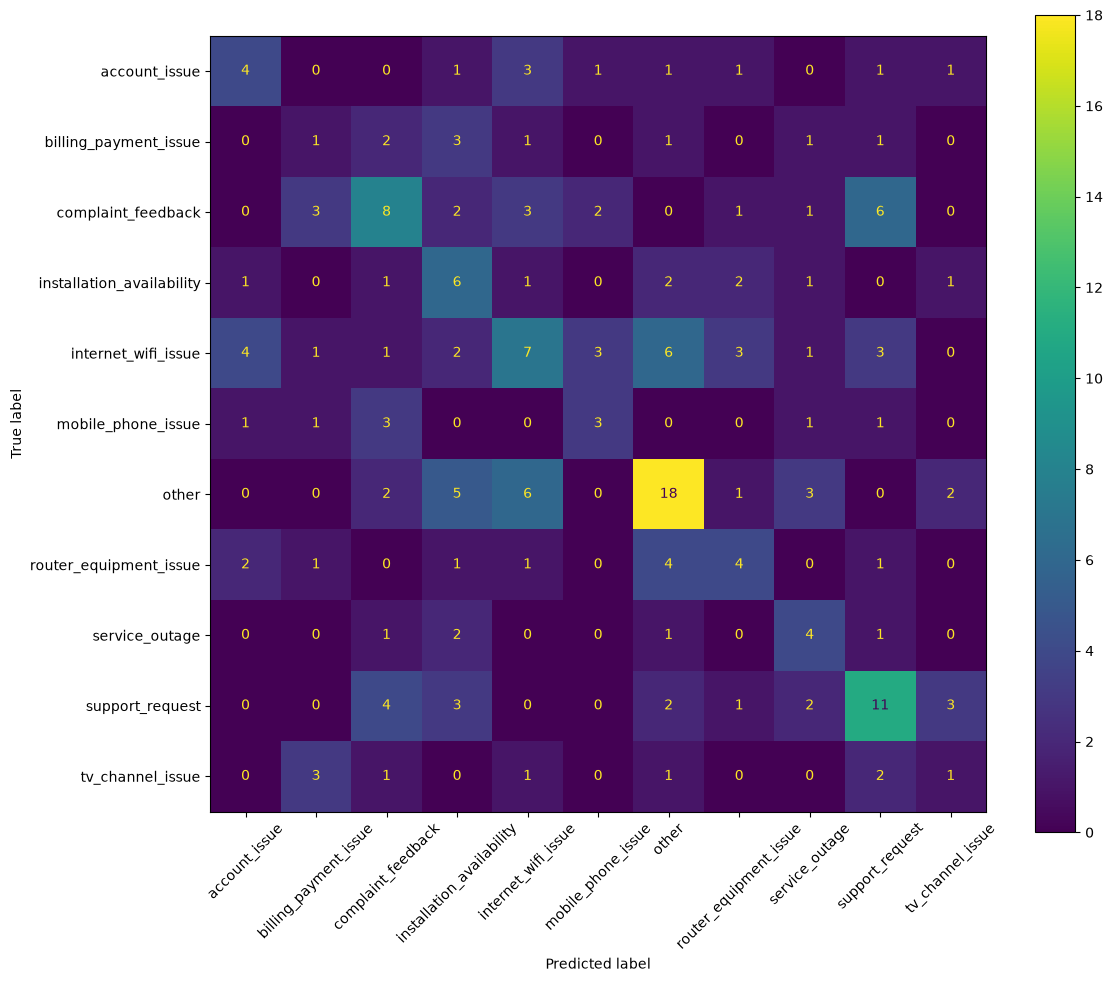

In [197]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y, y_pred, labels=sorted(y.unique()))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y.unique())
)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.show()

In [198]:
verizon["created_at"] = pd.to_datetime(verizon["created_at"])

verizon = verizon.sort_values("created_at")

print(verizon[["tweet_id", "inbound", "text"]].head(20).to_string(index=False))

C:\Users\This PC\AppData\Local\Temp\ipykernel_9648\1501362385.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  verizon["created_at"] = pd.to_datetime(verizon["created_at"])


 tweet_id  inbound                                                                                                                                                 text
   529315    False            @242560 Try disconnecting/reconnecting coax connections to the router and power cycling it? Then run test again on hardwired device. ^SEM
  1341577    False                                                                                              @432923 What channel are you looking for on Fios?  ^DFM
  1839373    False                                                                                                @551253 Can't see the photo. What does it state? ^STW
  1704143    False                                                                                     @516565 Please contact our friends @115990 for assistance.\n^TXA
  2765992    False                          @773563 This is not the perception we want you to have of us. Allow us to turn this around for you. How can we assis

In [199]:
# Customer messages that received a direct VerizonSupport reply
pairs = customer_messages.merge(
    agent_replies[["tweet_id", "in_response_to_tweet_id", "text"]],
    left_on="tweet_id",
    right_on="in_response_to_tweet_id",
    suffixes=("_customer", "_agent")
)

print("Customer-agent pairs:", len(pairs))

pairs[[
    "tweet_id_customer",
    "text_customer",
    "text_agent"
]].head(10)

Customer-agent pairs: 8660


,tweet_id_customer,text_customer,text_agent
0,35,"@VerizonSupport I finally got someone that helped me, thanks!",@115719 Awesome! If you ever need us we are just a tweet away.\n^HSB
1,41,@VerizonSupport What else can I provide? They refuse to help me because they cannot validate the account...,@115721 We would not be able to verify anything without authenticating your account.\n^JAY
2,44,"@VerizonSupport How? I have my phone number and email, that's it. How did I get equipment and service? I'm literally trying to pay and nobody can find me?",@115721 We can use the order number to locate the account but will need to do so in our secure one on one chat. Please follow and DM us. \n^HSB
3,51,"@VerizonSupport Don’t know, router is downstairs. But it’s just the WiFi Nothing connected to Ethernet",@115723 Is the light on top red?\n^JAY
4,53,@VerizonSupport Just randomly boots me offline there it goes again,@115723 Did the lights change on the router when this happened?\n^JAY
5,55,@VerizonSupport Yep,"@115723 Do you have our Fios service? When services go out, does the internet light on the router change color? ^BCW"
6,57,@VerizonSupport Cuts out every 20 minutes this is ridiculous,@115723 Are all your services cutting out?\n^ACM
7,1423,@VerizonSupport no! it just says amount due $27.04,@115988 Can you please follow and DM us. \n^ACM
8,2217,@VerizonSupport Banking. https://t.co/8535p04F9S,@116210 Put 0's in front of the number you have. ^RMD
9,2221,@VerizonSupport I’m standing in front of it,@116211 Press and hold the alarm silence / ONT reboot button for 30 seconds.\n^ACM


In [200]:
historical_pairs = pairs[[
    "tweet_id_customer",
    "text_customer",
    "text_agent"
]].copy()

historical_pairs.columns = [
    "customer_tweet_id",
    "customer_text",
    "agent_reply"
]

# Remove empty messages/replies
historical_pairs = historical_pairs.dropna(
    subset=["customer_text", "agent_reply"]
)

print("Historical pairs:", len(historical_pairs))
historical_pairs.head(10)

Historical pairs: 8660


,customer_tweet_id,customer_text,agent_reply
0,35,"@VerizonSupport I finally got someone that helped me, thanks!",@115719 Awesome! If you ever need us we are just a tweet away.\n^HSB
1,41,@VerizonSupport What else can I provide? They refuse to help me because they cannot validate the account...,@115721 We would not be able to verify anything without authenticating your account.\n^JAY
2,44,"@VerizonSupport How? I have my phone number and email, that's it. How did I get equipment and service? I'm literally trying to pay and nobody can find me?",@115721 We can use the order number to locate the account but will need to do so in our secure one on one chat. Please follow and DM us. \n^HSB
3,51,"@VerizonSupport Don’t know, router is downstairs. But it’s just the WiFi Nothing connected to Ethernet",@115723 Is the light on top red?\n^JAY
4,53,@VerizonSupport Just randomly boots me offline there it goes again,@115723 Did the lights change on the router when this happened?\n^JAY
5,55,@VerizonSupport Yep,"@115723 Do you have our Fios service? When services go out, does the internet light on the router change color? ^BCW"
6,57,@VerizonSupport Cuts out every 20 minutes this is ridiculous,@115723 Are all your services cutting out?\n^ACM
7,1423,@VerizonSupport no! it just says amount due $27.04,@115988 Can you please follow and DM us. \n^ACM
8,2217,@VerizonSupport Banking. https://t.co/8535p04F9S,@116210 Put 0's in front of the number you have. ^RMD
9,2221,@VerizonSupport I’m standing in front of it,@116211 Press and hold the alarm silence / ONT reboot button for 30 seconds.\n^ACM


In [201]:
golden_ids = set(golden_set["tweet_id"])

historical_pairs_clean = historical_pairs[
    ~historical_pairs["customer_tweet_id"].isin(golden_ids)
].copy()

print("Historical pairs before:", len(historical_pairs))
print("Historical pairs after :", len(historical_pairs_clean))
print("Golden examples removed:", 
      len(historical_pairs) - len(historical_pairs_clean))

Historical pairs before: 8660
Historical pairs after : 8523
Golden examples removed: 137


TF-IDF retriever

In [202]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

retriever_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

historical_matrix = retriever_vectorizer.fit_transform(
    historical_pairs_clean["customer_text"]
)

print("Historical cases:", historical_matrix.shape[0])
print("TF-IDF features:", historical_matrix.shape[1])

Historical cases: 8523
TF-IDF features: 8506


In [203]:
test_message = golden_set.iloc[0]["text"]

query_vector = retriever_vectorizer.transform([test_message])

similarities = cosine_similarity(
    query_vector,
    historical_matrix
).flatten()

top_indices = similarities.argsort()[-3:][::-1]

print("NEW CUSTOMER MESSAGE:")
print(test_message)
print("\nTOP 3 HISTORICAL CASES:\n")

for rank, idx in enumerate(top_indices, 1):
    row = historical_pairs_clean.iloc[idx]
    
    print(f"--- Case {rank} | Similarity: {similarities[idx]:.3f} ---")
    print("Customer:", row["customer_text"])
    print("Agent   :", row["agent_reply"])
    print()

NEW CUSTOMER MESSAGE:
@VerizonSupport It’s a cellular account

TOP 3 HISTORICAL CASES:

--- Case 1 | Similarity: 1.000 ---
Customer: @VerizonSupport Cellular account
Agent   : @743287 Let’s get you over to our partner’s @115990 and they will assist you with your wireless concerns.
^TDC

--- Case 2 | Similarity: 0.610 ---
Customer: @VerizonSupport It's a cellular
Agent   : @160380 We'll refer this to our wireless colleagues @115990 since we handle Fios and DSL accounts. 
^HSB

--- Case 3 | Similarity: 0.610 ---
Customer: @VerizonSupport Cellular
Agent   : @705476 Thanks for the tweet! Let us get our partners at @115990 to help you from here.
^JAY



In [204]:
from src.retrieval import retrieve_similar_cases

results = retrieve_similar_cases(
    "My Fios internet keeps disconnecting",
    historical_pairs_clean,
    retriever_vectorizer,
    historical_matrix,
    top_k=3
)

results

ModuleNotFoundError: No module named 'src'

In [ ]:
import re

def clean_tweet(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # Remove Twitter usernames
    text = re.sub(r"@\w+", "", text)

    # Remove agent signature such as ^CAR, ^TXA
    text = re.sub(r"\^[A-Z]{2,5}\b", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


historical_pairs_clean["customer_text_clean"] = (
    historical_pairs_clean["customer_text"].apply(clean_tweet)
)

historical_pairs_clean["agent_reply_clean"] = (
    historical_pairs_clean["agent_reply"].apply(clean_tweet)
)

historical_pairs_clean[
    ["customer_text_clean", "agent_reply_clean"]
].head(5)

,customer_text_clean,agent_reply_clean
0,"I finally got someone that helped me, thanks!",Awesome! If you ever need us we are just a tweet away.
1,What else can I provide? They refuse to help me because they cannot validate the account...,We would not be able to verify anything without authenticating your account.
2,"How? I have my phone number and email, that's it. How did I get equipment and service? I'm literally trying to pay and nobody can find me?",We can use the order number to locate the account but will need to do so in our secure one on one chat. Please follow and DM us.
3,"Don’t know, router is downstairs. But it’s just the WiFi Nothing connected to Ethernet",Is the light on top red?
4,Just randomly boots me offline there it goes again,Did the lights change on the router when this happened?


In [ ]:
import sys
sys.path.append("..")

In [ ]:
from src.retrieval import build_retriever

In [ ]:
historical_pairs_clean, retriever_vectorizer, historical_matrix = build_retriever(
    historical_pairs_clean
)

print("Historical cases:", historical_matrix.shape[0])
print("TF-IDF features:", historical_matrix.shape[1])

Historical cases: 8523
TF-IDF features: 7617


In [ ]:
golden_ids = set(golden_set["tweet_id"])

historical_pairs_clean = historical_pairs[
    ~historical_pairs["customer_tweet_id"].isin(golden_ids)
].copy()

print("Historical pairs before removing golden:", len(historical_pairs))
print("Historical pairs after removing golden:", len(historical_pairs_clean))

Historical pairs before removing golden: 8660
Historical pairs after removing golden: 8523


In [ ]:
def retrieve_similar_cases(query, top_k=3):
    query_vector = retriever_vectorizer.transform([query])

    similarities = cosine_similarity(
        query_vector,
        historical_matrix
    ).flatten()

    top_indices = similarities.argsort()[-top_k:][::-1]

    results = historical_pairs_clean.iloc[top_indices].copy()
    results["similarity"] = similarities[top_indices]

    return results[[
        "customer_text_clean",
        "agent_reply_clean",
        "similarity"
    ]]


results = retrieve_similar_cases(
    "My Fios internet keeps disconnecting",
    top_k=3
)

results

,customer_text_clean,agent_reply_clean,similarity
3768,Fios internet,Do you have an amber or red light on your router?,0.562972
2936,FiOS. Internet and Video is out.,What lights are lit on your battery backup unit?,0.466067
7557,My internet keeps cutting in and out.,"When your connection cuts out, are all devices disconnected? Do the lights on the router change colors?",0.460898


In [ ]:
def build_retrieval_context(query, top_k=3):
    results = retrieve_similar_cases(query, top_k=top_k)

    context = []

    for i, row in results.iterrows():
        context.append(
            f"Historical customer issue: {row['customer_text_clean']}\n"
            f"Historical Verizon response: {row['agent_reply_clean']}"
        )

    return "\n\n".join(context)


context = build_retrieval_context(
    "My Fios internet keeps disconnecting",
    top_k=3
)

print(context)

Historical customer issue: Fios internet
Historical Verizon response: Do you have an amber or red light on your router?

Historical customer issue: FiOS. Internet and Video is out.
Historical Verizon response: What lights are lit on your battery backup unit?

Historical customer issue: My internet keeps cutting in and out.
Historical Verizon response: When your connection cuts out, are all devices disconnected? Do the lights on the router change colors?


draft prompt

In [ ]:
def build_reply_prompt(customer_message, context):
    return f"""
You are a Verizon customer support assistant.

Customer message:
{customer_message}

Historical Verizon support examples:
{context}

Task:
Draft a concise and helpful customer support reply.

Rules:
- Use the historical responses as evidence for how Verizon handled similar issues.
- Do not invent troubleshooting steps that are not supported by the examples.
- If the historical examples suggest asking a diagnostic question, ask that question.
- Do not mention that you are using historical examples.
- Do not include Twitter usernames or agent signatures.
"""

prompt = build_reply_prompt(
    "My Fios internet keeps disconnecting",
    context
)

print(prompt)


You are a Verizon customer support assistant.

Customer message:
My Fios internet keeps disconnecting

Historical Verizon support examples:
Historical customer issue: Fios internet
Historical Verizon response: Do you have an amber or red light on your router?

Historical customer issue: FiOS. Internet and Video is out.
Historical Verizon response: What lights are lit on your battery backup unit?

Historical customer issue: My internet keeps cutting in and out.
Historical Verizon response: When your connection cuts out, are all devices disconnected? Do the lights on the router change colors?

Task:
Draft a concise and helpful customer support reply.

Rules:
- Use the historical responses as evidence for how Verizon handled similar issues.
- Do not invent troubleshooting steps that are not supported by the examples.
- If the historical examples suggest asking a diagnostic question, ask that question.
- Do not mention that you are using historical examples.
- Do not include Twitter usern

In [ ]:
from src.agent import support_agent

In [ ]:
agent_result = support_agent(
    "My Fios internet keeps disconnecting",
    final_intent_model,
    historical_pairs_clean,
    retriever_vectorizer,
    historical_matrix,
    gemini_client=None,
    top_k=3
)

print("Intent:", agent_result["intent"])
print("Intent confidence:", agent_result["intent_confidence"])
print("Retrieval similarity:", agent_result["retrieval_similarity"])
print("Decision:", agent_result["decision"])
print("Reason:", agent_result["reason"])
print("Reply source:", agent_result["reply_source"])
print("Draft reply:", agent_result["draft_reply"])

Intent: internet_wifi_issue
Intent confidence: 0.235
Retrieval similarity: 0.563
Decision: AUTO_HANDLE
Reason: The issue appears suitable for automated handling based on historical support evidence.
Reply source: historical_fallback
Draft reply: Do you have an amber or red light on your router?


In [ ]:
def draft_grounded_reply(results):
    best_reply = results.iloc[0]["agent_reply_clean"]
    return best_reply


draft = draft_grounded_reply(
    retrieve_similar_cases(
        "My Fios internet keeps disconnecting",
        top_k=3
    )
)

print("Draft reply:")
print(draft)

Draft reply:
Do you have an amber or red light on your router?


In [ ]:
def escalation_decision(customer_message, intent):
    text = customer_message.lower()

    escalation_keywords = [
        "fraud",
        "unauthorized",
        "identity theft",
        "legal",
        "lawyer",
        "lawsuit",
        "complaint",
        "refund",
        "charged",
        "payment",
        "account",
        "cannot verify",
        "authentication"
    ]

    if any(keyword in text for keyword in escalation_keywords):
        return {
            "decision": "ESCALATE",
            "reason": "The issue may require account-specific, payment-related, or human support."
        }

    if intent in [
        "billing_payment_issue",
        "account_issue"
    ]:
        return {
            "decision": "ESCALATE",
            "reason": f"{intent} may require secure account-specific handling."
        }

    return {
        "decision": "AUTO_HANDLE",
        "reason": "The issue appears suitable for standard troubleshooting based on historical support cases."
    }


decision = escalation_decision(
    "My Fios internet keeps disconnecting",
    "internet_wifi_issue"
)

decision

{'decision': 'AUTO_HANDLE',
 'reason': 'The issue appears suitable for standard troubleshooting based on historical support cases.'}

In [ ]:
def support_agent_v1(customer_message):
    # 1. Intent prediction
    model.fit(X, y)
    predicted_intent = model.predict([customer_message])[0]

    # 2. Retrieve historical cases
    retrieved = retrieve_similar_cases(
        customer_message,
        top_k=3
    )

    # 3. Draft grounded reply
    draft_reply = retrieved.iloc[0]["agent_reply_clean"]

    # 4. Escalation decision
    decision = escalation_decision(
        customer_message,
        predicted_intent
    )

    return {
        "intent": predicted_intent,
        "draft_reply": draft_reply,
        "decision": decision["decision"],
        "reason": decision["reason"],
        "retrieved_cases": retrieved
    }


# Test
result = support_agent_v1(
    "My Fios internet keeps disconnecting"
)

print("Intent:", result["intent"])
print("Draft:", result["draft_reply"])
print("Decision:", result["decision"])
print("Reason:", result["reason"])

Intent: internet_wifi_issue
Draft: Do you have an amber or red light on your router?
Decision: AUTO_HANDLE
Reason: The issue appears suitable for standard troubleshooting based on historical support cases.


In [ ]:
golden_predictions = []

model.fit(X, y)

for message in golden_set["text"]:
    prediction = model.predict([message])[0]
    golden_predictions.append(prediction)

golden_eval = golden_set.copy()
golden_eval["predicted_intent"] = golden_predictions

golden_eval[
    ["text", "intent", "predicted_intent"]
].head(10)

,text,intent,predicted_intent
0,@VerizonSupport It’s a cellular account,account_issue,account_issue
1,@VerizonSupport I'll send you a screenshot.,other,other
2,@VerizonSupport Multiple people have been having the same problem,service_outage,service_outage
3,@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !,complaint_feedback,complaint_feedback
4,@VerizonSupport FIOS-V0MQP,account_issue,account_issue
5,@VerizonSupport hi! i got someone…surprisingly faster than the robot lady said. which is good news,support_request,support_request
6,"@VerizonSupport It’s been time honestly, I’m just hoping my building gets fios soon is there any way to request it ?",installation_availability,installation_availability
7,@VerizonSupport Give me a number to call now. Forget this DM.,support_request,support_request
8,"@VerizonSupport Wait a second, there are no contracts with Spectrum / Brighthouse",other,other
9,@VerizonSupport Well it could be but somehow the chat was disconnected after I finish typing everything for the millionth time 😡,support_request,support_request


In [ ]:
retrieval_results = []

for _, row in golden_set.iterrows():
    results = retrieve_similar_cases(
        row["text"],
        top_k=1
    )

    best = results.iloc[0]

    retrieval_results.append({
        "tweet_id": row["tweet_id"],
        "golden_intent": row["intent"],
        "customer_text": row["text"],
        "historical_customer": best["customer_text_clean"],
        "historical_reply": best["agent_reply_clean"],
        "similarity": best["similarity"]
    })

retrieval_eval = pd.DataFrame(retrieval_results)

print("Golden examples evaluated:", len(retrieval_eval))
retrieval_eval.head(10)

Golden examples evaluated: 200


,tweet_id,golden_intent,customer_text,historical_customer,historical_reply,similarity
0,498663,account_issue,@VerizonSupport It’s a cellular account,Cellular account,Let’s get you over to our partner’s and they will assist you with your wireless concerns.,1.000000
1,1656972,other,@VerizonSupport I'll send you a screenshot.,Naw... here Issa screenshot,"Thank you. Can you try uninstalling the app, rebooting the device, then re-installing the app?",0.735712
2,223798,service_outage,@VerizonSupport Multiple people have been having the same problem,I am having a problem with bofa,Not with these right? How can we help you this evening?,0.676780
3,2648727,complaint_feedback,@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !,That’s helpful,"Apologies, please refer to this link for the latest information:",0.343214
4,968869,account_issue,@VerizonSupport FIOS-V0MQP,Fios,"We are following you now, feel free to DM us your questions.",1.000000
5,388681,support_request,@VerizonSupport hi! i got someone…surprisingly faster than the robot lady said. which is good news,Hi I got the reference number they said to use 76751,We will follow up and have a tech get this resolved.,0.358530
6,828149,installation_availability,"@VerizonSupport It’s been time honestly, I’m just hoping my building gets fios soon is there any way to request it ?",How soon can you be here?,For an install?,0.338530
7,1820523,support_request,@VerizonSupport Give me a number to call now. Forget this DM.,DM,Please initiate the DM with your results.,0.461560
8,2838857,other,"@VerizonSupport Wait a second, there are no contracts with Spectrum / Brighthouse",Not this second,"You will not get all of your channels on the app when you are not at the premise. You can use the network app, to watch shows.",0.453789
9,1743204,support_request,@VerizonSupport Well it could be but somehow the chat was disconnected after I finish typing everything for the millionth time 😡,No my service was mistakenly disconnected but issue with recon nect,Do you have High Speed Internet or Fios?,0.305775


In [ ]:
retrieval_eval["similarity"].describe()

count    200.000000
mean       0.557514
std        0.254860
min        0.000000
25%        0.392726
50%        0.494864
75%        0.689274
max        1.000000
Name: similarity, dtype: float64

In [ ]:
model.fit(X, y)

test_message = "My Fios internet keeps disconnecting"

probabilities = model.predict_proba([test_message])[0]
classes = model.classes_

intent_confidence = sorted(
    zip(classes, probabilities),
    key=lambda x: x[1],
    reverse=True
)

print("Intent confidence:")
for intent, prob in intent_confidence[:5]:
    print(f"{intent}: {prob:.3f}")

Intent confidence:
internet_wifi_issue: 0.148
account_issue: 0.131
installation_availability: 0.115
complaint_feedback: 0.085
mobile_phone_issue: 0.084


In [ ]:
confidence_results = []

model.fit(X, y)

for _, row in golden_set.iterrows():
    message = row["text"]

    probabilities = model.predict_proba([message])[0]
    predicted_idx = probabilities.argmax()

    confidence_results.append({
        "tweet_id": row["tweet_id"],
        "true_intent": row["intent"],
        "predicted_intent": model.classes_[predicted_idx],
        "intent_confidence": probabilities[predicted_idx]
    })

confidence_eval = pd.DataFrame(confidence_results)

print(confidence_eval["intent_confidence"].describe())

count    200.000000
mean       0.224487
std        0.068194
min        0.115818
25%        0.171099
50%        0.214315
75%        0.276016
max        0.518265
Name: intent_confidence, dtype: float64


In [ ]:
confidence_eval["correct"] = (
    confidence_eval["true_intent"] ==
    confidence_eval["predicted_intent"]
)

confidence_eval.groupby(
    pd.cut(
        confidence_eval["intent_confidence"],
        bins=[0, 0.15, 0.20, 0.25, 0.30, 0.40, 1.0]
    ),
    observed=False
)["correct"].agg(
    ["count", "mean"]
)

,count,mean
intent_confidence,,
"(0.0, 0.15]",20,0.800000
"(0.15, 0.2]",64,0.921875
"(0.2, 0.25]",53,0.924528
"(0.25, 0.3]",32,0.968750
"(0.3, 0.4]",29,1.000000
"(0.4, 1.0]",2,1.000000


In [ ]:
from sklearn.model_selection import cross_val_predict

oof_probabilities = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

oof_predictions = model.classes_[oof_probabilities.argmax(axis=1)]
oof_confidence = oof_probabilities.max(axis=1)

oof_confidence_eval = golden_set[[
    "tweet_id",
    "intent"
]].copy()

oof_confidence_eval["predicted_intent"] = oof_predictions
oof_confidence_eval["intent_confidence"] = oof_confidence

oof_confidence_eval["correct"] = (
    oof_confidence_eval["intent"] ==
    oof_confidence_eval["predicted_intent"]
)

print(oof_confidence_eval["intent_confidence"].describe())
print("\nOverall accuracy:",
      round(oof_confidence_eval["correct"].mean(), 4))

count    200.000000
mean       0.148194
std        0.038110
min        0.107124
25%        0.123879
50%        0.134318
75%        0.157560
max        0.374884
Name: intent_confidence, dtype: float64

Overall accuracy: 0.335


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

better_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True
    )),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

better_scores = cross_val_score(
    better_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Fold accuracies:", better_scores)
print("Mean CV accuracy:", round(better_scores.mean(), 4))

Fold accuracies: [0.4   0.55  0.5   0.5   0.475]
Mean CV accuracy: 0.485


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

better_y_pred = cross_val_predict(
    better_model,
    X,
    y,
    cv=cv
)

print(classification_report(
    y,
    better_y_pred,
    zero_division=0
))

                           precision    recall  f1-score   support

            account_issue       0.50      0.38      0.43        13
    billing_payment_issue       0.45      0.50      0.48        10
       complaint_feedback       0.43      0.46      0.44        26
installation_availability       0.38      0.33      0.36        15
      internet_wifi_issue       0.54      0.48      0.51        31
       mobile_phone_issue       0.50      0.60      0.55        10
                    other       0.56      0.73      0.64        37
   router_equipment_issue       0.40      0.29      0.33        14
           service_outage       0.30      0.33      0.32         9
          support_request       0.46      0.42      0.44        26
         tv_channel_issue       0.67      0.44      0.53         9

                 accuracy                           0.48       200
                macro avg       0.47      0.45      0.46       200
             weighted avg       0.48      0.48      0.48    

In [ ]:
better_oof_prob = cross_val_predict(
    better_model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

classes = sorted(y.unique())

better_oof_pred = [
    classes[i]
    for i in better_oof_prob.argmax(axis=1)
]

better_oof_conf = better_oof_prob.max(axis=1)

print("Mean confidence:",
      round(better_oof_conf.mean(), 4))

print("Max confidence:",
      round(better_oof_conf.max(), 4))

print("\nCorrect predictions:",
      sum(better_oof_pred[i] == y.iloc[i]
          for i in range(len(y))),
      "/",
      len(y))

Mean confidence: 0.1499
Max confidence: 0.3224

Correct predictions: 97 / 200


In [ ]:
test_message = "My Fios internet keeps disconnecting"

# Fit best classifier on the labelled golden examples
better_model.fit(X, y)

# Intent
predicted_intent = better_model.predict([test_message])[0]

# Intent confidence
intent_probs = better_model.predict_proba([test_message])[0]
intent_confidence = intent_probs.max()

# Historical retrieval
retrieved = retrieve_similar_cases(
    test_message,
    top_k=3
)

best_similarity = retrieved.iloc[0]["similarity"]

print("Customer:", test_message)
print("Predicted intent:", predicted_intent)
print("Intent confidence:", round(intent_confidence, 3))
print("Best historical similarity:", round(best_similarity, 3))
print("\nHistorical evidence:")
print(retrieved.to_string(index=False))

Customer: My Fios internet keeps disconnecting
Predicted intent: internet_wifi_issue
Intent confidence: 0.235
Best historical similarity: 0.563

Historical evidence:
                  customer_text_clean                                                                                       agent_reply_clean  similarity
                        Fios internet                                                       Do you have an amber or red light on your router?    0.562972
     FiOS. Internet and Video is out.                                                        What lights are lit on your battery backup unit?    0.466067
My internet keeps cutting in and out. When your connection cuts out, are all devices disconnected? Do the lights on the router change colors?    0.460898


In [ ]:
def decide_handling(intent, intent_confidence, retrieval_similarity):
    # High-risk intents should not be auto-handled
    if intent in ["billing_payment_issue", "account_issue"]:
        return "ESCALATE", "Account or payment-related issue may require secure human handling."

    # Very weak retrieval evidence
    if retrieval_similarity < 0.30:
        return "ESCALATE", "No sufficiently similar historical support case was found."

    # Reasonably relevant historical evidence
    if retrieval_similarity >= 0.40:
        return "AUTO_HANDLE", "Relevant historical troubleshooting evidence is available."

    return "ESCALATE", "Historical evidence is too weak for confident automated handling."


decision, reason = decide_handling(
    predicted_intent,
    intent_confidence,
    best_similarity
)

print("Decision:", decision)
print("Reason:", reason)

Decision: AUTO_HANDLE
Reason: Relevant historical troubleshooting evidence is available.


In [ ]:
decision_results = []

for _, row in retrieval_eval.iterrows():
    intent = row["golden_intent"]

    decision, reason = decide_handling(
        intent=intent,
        intent_confidence=0.0,  # current rule doesn't use it
        retrieval_similarity=row["similarity"]
    )

    decision_results.append({
        "tweet_id": row["tweet_id"],
        "intent": intent,
        "similarity": row["similarity"],
        "decision": decision
    })

decision_eval = pd.DataFrame(decision_results)

print(decision_eval["decision"].value_counts())

decision
AUTO_HANDLE    129
ESCALATE        71
Name: count, dtype: int64


In [ ]:
auto_cases = retrieval_eval[
    retrieval_eval["similarity"] >= 0.40
].sample(n=10, random_state=42)

auto_cases[
    [
        "golden_intent",
        "customer_text",
        "historical_customer",
        "historical_reply",
        "similarity"
    ]
]

,golden_intent,customer_text,historical_customer,historical_reply,similarity
64,service_outage,@VerizonSupport Fios! And no service since yesterday,"That’s what I mean, if I get fios service when I move in a few weeks",We can check if the offer is still available. Please follow and DM us at your convenience.,0.523032
139,other,@VerizonSupport I️ don’t know how to do that,No I don't know how to do that,"Turn the router off by unplugging it and then 30 seconds later, plug it back in. Last reboot your cable box.",1.000000
39,account_issue,"@VerizonSupport YO, you cant look at my account info and see wtf is going on with my account. DAMN!",Opened up my fios account to look up my account number and it’s not my account. Someone with the same last name. What’s up with this?,That's not good at all! Allow us to take a look. Please follow and DM so we can continue.,0.434293
27,complaint_feedback,@VerizonSupport @115990 Your story is tiresome,🤔 oh brother... Haha it's just a story!,Doh...understood. If you ever do need assistance with your land based services we will be here for you 24x7.,0.499654
59,complaint_feedback,@VerizonSupport I don't like strangers knocking at my door... I think it's safe to say my neighbors don't either because most people don't answer.,We don't have one.,Please follow and DM so we can continue.,0.543259
167,account_issue,@VerizonSupport Somehow my password got changed for some reason.,Done. Nothing seems to have changed.,"Can you open the cover door on the unit? Can you disconnect the battery and unplug the power from the electrical outlet? Then you have to wait 3 minutes and connect your battery back, then wait an...",0.502491
41,router_equipment_issue,@VerizonSupport just the main one in the living room,In the living room,"Have you tried the Wireless Wizard on ""In Home Agent""? Here is a link to it:",0.849579
118,installation_availability,@VerizonSupport We have - but you’re not available here... wish you were,Not available yet.,"Hopefully we will get it to you soon, be sure to sign up for notifications via email on the link we sent.",0.624111
94,internet_wifi_issue,@VerizonSupport I need it faster than what it is I need hi speed internet,What besides the death certificate would I need,That should be it.,0.551087
26,router_equipment_issue,@VerizonSupport This is what I'm seeing. It's mounted about 7' off ground in basement https://t.co/dTVCwFGbfm,basement...,Could you press the alarm silence on it for 25 seconds and then reboot your router once more please.,0.543025


In [ ]:
judge_sample = retrieval_eval.sample(
    n=20,
    random_state=42
).reset_index(drop=True)

judge_sample[
    [
        "golden_intent",
        "customer_text",
        "historical_customer",
        "historical_reply",
        "similarity"
    ]
]

,golden_intent,customer_text,historical_customer,historical_reply,similarity
0,other,@VerizonSupport Ok,Ok.,"Please follow us, so we can DM you.",1.000000
1,router_equipment_issue,"@VerizonSupport Went with channel 11 for 2.4GHz, 161 for 5GHz. Laptop can now pickup the 5GHz band again but only when close to the router, seems installed Extender isn't working very far, iPhone ...",Both my macbooks and my iphone are connected to the 5Ghz,Can you connect them to the 2.4 and test.,0.407992
2,service_outage,"@VerizonSupport According to the site, everything is good.",They’re good,If that is the case you may want to reseat the connections. This may make for better contact since the issue is isolated to just 1 TV.,0.470145
3,support_request,"@VerizonSupport Tired of being rerouted to different departments, only to end back up in customer services",That’s you generic phone number for customer services..,"That's correct, The number to our Financial Service Team is 888 338-9333. They can be reached after 8:30 am tomorrow morning.",0.434161
4,billing_payment_issue,@VerizonSupport Nobody can give me answers or return my money how is this right ?,Right next to it,Please follow and DM us for assistance.,0.401375
5,account_issue,@VerizonSupport There is no button to click. My dilemma,I can’t find the button,"If you do not see an alarm silence button on that unit to hold down for 20 seconds, check the power supply plugged in to an outlet for a reset button located on it.",0.652099
6,internet_wifi_issue,@VerizonSupport Wired ethernet directly to the ONT.,wired ethernet,"Oh no, Can you power cycle the router by unplugging the power cable then plugging it back in? It takes about 3 min. to reboot.",0.660331
7,internet_wifi_issue,@VerizonSupport I could look. I don’t understand why the internet is so bad though. I lose connection all the time,"I’m wireless, lights do change, and other devices lose connection",Thank you. Is your router's internet light turning red when you lose connection?,0.394485
8,internet_wifi_issue,"@VerizonSupport Yes, I own a custom AV installation business. This is what I do. It's on your end.",Installation,We can see if we can find the tech. Please follow and DM us.,0.487022
9,other,"@VerizonSupport yes, both version 5.9",version 5.9,Is that the same on both the iPad and the iPhone that is working?,0.918743


In [ ]:
retrieval_judgments = [
    "RELEVANT",
    "RELEVANT",
    "PARTIAL",
    "PARTIAL",
    "IRRELEVANT",
    "IRRELEVANT",
    "RELEVANT",
    "RELEVANT",
    "PARTIAL",
    "RELEVANT",
    "PARTIAL",
    "PARTIAL",
    "RELEVANT",
    "IRRELEVANT",
    "PARTIAL",
    "IRRELEVANT",
    "PARTIAL",
    "RELEVANT",
    "PARTIAL",
    "RELEVANT"
]

judge_sample["retrieval_judgment"] = retrieval_judgments

print(judge_sample["retrieval_judgment"].value_counts())

judge_sample[
    [
        "golden_intent",
        "similarity",
        "retrieval_judgment"
    ]
]

retrieval_judgment
RELEVANT      8
PARTIAL       8
IRRELEVANT    4
Name: count, dtype: int64


,golden_intent,similarity,retrieval_judgment
0,other,1.000000,RELEVANT
1,router_equipment_issue,0.407992,RELEVANT
2,service_outage,0.470145,PARTIAL
3,support_request,0.434161,PARTIAL
4,billing_payment_issue,0.401375,IRRELEVANT
5,account_issue,0.652099,IRRELEVANT
6,internet_wifi_issue,0.660331,RELEVANT
7,internet_wifi_issue,0.394485,RELEVANT
8,internet_wifi_issue,0.487022,PARTIAL
9,other,0.918743,RELEVANT


In [ ]:
retrieval_counts = judge_sample["retrieval_judgment"].value_counts()

relevant_rate = (
    retrieval_counts.get("RELEVANT", 0)
    / len(judge_sample)
)

non_irrelevant_rate = (
    (retrieval_counts.get("RELEVANT", 0)
     + retrieval_counts.get("PARTIAL", 0))
    / len(judge_sample)
)

print("Clearly relevant retrieval rate:",
      round(relevant_rate, 3))

print("At least partially relevant rate:",
      round(non_irrelevant_rate, 3))

Clearly relevant retrieval rate: 0.4
At least partially relevant rate: 0.8


In [ ]:
reply_audit = judge_sample.copy()

reply_audit["draft_reply"] = (
    reply_audit["historical_reply"]
)

reply_audit[
    [
        "golden_intent",
        "customer_text",
        "historical_customer",
        "draft_reply",
        "similarity",
        "retrieval_judgment"
    ]
]

,golden_intent,customer_text,historical_customer,draft_reply,similarity,retrieval_judgment
0,other,@VerizonSupport Ok,Ok.,"Please follow us, so we can DM you.",1.000000,RELEVANT
1,router_equipment_issue,"@VerizonSupport Went with channel 11 for 2.4GHz, 161 for 5GHz. Laptop can now pickup the 5GHz band again but only when close to the router, seems installed Extender isn't working very far, iPhone ...",Both my macbooks and my iphone are connected to the 5Ghz,Can you connect them to the 2.4 and test.,0.407992,RELEVANT
2,service_outage,"@VerizonSupport According to the site, everything is good.",They’re good,If that is the case you may want to reseat the connections. This may make for better contact since the issue is isolated to just 1 TV.,0.470145,PARTIAL
3,support_request,"@VerizonSupport Tired of being rerouted to different departments, only to end back up in customer services",That’s you generic phone number for customer services..,"That's correct, The number to our Financial Service Team is 888 338-9333. They can be reached after 8:30 am tomorrow morning.",0.434161,PARTIAL
4,billing_payment_issue,@VerizonSupport Nobody can give me answers or return my money how is this right ?,Right next to it,Please follow and DM us for assistance.,0.401375,IRRELEVANT
5,account_issue,@VerizonSupport There is no button to click. My dilemma,I can’t find the button,"If you do not see an alarm silence button on that unit to hold down for 20 seconds, check the power supply plugged in to an outlet for a reset button located on it.",0.652099,IRRELEVANT
6,internet_wifi_issue,@VerizonSupport Wired ethernet directly to the ONT.,wired ethernet,"Oh no, Can you power cycle the router by unplugging the power cable then plugging it back in? It takes about 3 min. to reboot.",0.660331,RELEVANT
7,internet_wifi_issue,@VerizonSupport I could look. I don’t understand why the internet is so bad though. I lose connection all the time,"I’m wireless, lights do change, and other devices lose connection",Thank you. Is your router's internet light turning red when you lose connection?,0.394485,RELEVANT
8,internet_wifi_issue,"@VerizonSupport Yes, I own a custom AV installation business. This is what I do. It's on your end.",Installation,We can see if we can find the tech. Please follow and DM us.,0.487022,PARTIAL
9,other,"@VerizonSupport yes, both version 5.9",version 5.9,Is that the same on both the iPad and the iPhone that is working?,0.918743,RELEVANT


In [ ]:
reply_audit["relevance"] = None
reply_audit["groundedness"] = None
reply_audit["helpfulness"] = None
reply_audit["safety"] = None

reply_audit[
    [
        "customer_text",
        "historical_customer",
        "draft_reply",
        "relevance",
        "groundedness",
        "helpfulness",
        "safety",
    ]
].head(20)

,customer_text,historical_customer,draft_reply,relevance,groundedness,helpfulness,safety
0,@VerizonSupport Ok,Ok.,"Please follow us, so we can DM you.",None,None,None,None
1,"@VerizonSupport Went with channel 11 for 2.4GHz, 161 for 5GHz. Laptop can now pickup the 5GHz band again but only when close to the router, seems installed Extender isn't working very far, iPhone ...",Both my macbooks and my iphone are connected to the 5Ghz,Can you connect them to the 2.4 and test.,None,None,None,None
2,"@VerizonSupport According to the site, everything is good.",They’re good,If that is the case you may want to reseat the connections. This may make for better contact since the issue is isolated to just 1 TV.,None,None,None,None
3,"@VerizonSupport Tired of being rerouted to different departments, only to end back up in customer services",That’s you generic phone number for customer services..,"That's correct, The number to our Financial Service Team is 888 338-9333. They can be reached after 8:30 am tomorrow morning.",None,None,None,None
4,@VerizonSupport Nobody can give me answers or return my money how is this right ?,Right next to it,Please follow and DM us for assistance.,None,None,None,None
5,@VerizonSupport There is no button to click. My dilemma,I can’t find the button,"If you do not see an alarm silence button on that unit to hold down for 20 seconds, check the power supply plugged in to an outlet for a reset button located on it.",None,None,None,None
6,@VerizonSupport Wired ethernet directly to the ONT.,wired ethernet,"Oh no, Can you power cycle the router by unplugging the power cable then plugging it back in? It takes about 3 min. to reboot.",None,None,None,None
7,@VerizonSupport I could look. I don’t understand why the internet is so bad though. I lose connection all the time,"I’m wireless, lights do change, and other devices lose connection",Thank you. Is your router's internet light turning red when you lose connection?,None,None,None,None
8,"@VerizonSupport Yes, I own a custom AV installation business. This is what I do. It's on your end.",Installation,We can see if we can find the tech. Please follow and DM us.,None,None,None,None
9,"@VerizonSupport yes, both version 5.9",version 5.9,Is that the same on both the iPad and the iPhone that is working?,None,None,None,None


In [ ]:
# Display one case at a time for manual evaluation

for i, row in reply_audit.iterrows():
    print("=" * 80)
    print("CASE:", i)
    print("\nCUSTOMER:")
    print(row["customer_text"])

    print("\nHISTORICAL CUSTOMER:")
    print(row["historical_customer"])

    print("\nDRAFT REPLY:")
    print(row["draft_reply"])

    print("\nGive scores: 0 = Poor, 1 = Partial, 2 = Good")
    print("Relevance | Groundedness | Helpfulness | Safety")
    print("=" * 80)

CASE: 0

CUSTOMER:
@VerizonSupport Ok

HISTORICAL CUSTOMER:
Ok.

DRAFT REPLY:
Please follow us, so we can DM you.

Give scores: 0 = Poor, 1 = Partial, 2 = Good
Relevance | Groundedness | Helpfulness | Safety
CASE: 1

CUSTOMER:
@VerizonSupport Went with channel 11 for 2.4GHz, 161 for 5GHz. Laptop can now pickup the 5GHz band again but only when close to the router, seems installed Extender isn't working very far, iPhone still not even recognizing 5GHz.

HISTORICAL CUSTOMER:
Both my macbooks and my iphone are connected to the 5Ghz

DRAFT REPLY:
Can you connect them to the 2.4 and test.

Give scores: 0 = Poor, 1 = Partial, 2 = Good
Relevance | Groundedness | Helpfulness | Safety
CASE: 2

CUSTOMER:
@VerizonSupport According to the site,  everything is good.

HISTORICAL CUSTOMER:
They’re good

DRAFT REPLY:
If that is the case you may want to reseat the connections. This may make for better contact since the issue is isolated to just 1 TV.

Give scores: 0 = Poor, 1 = Partial, 2 = Good
Releva

In [ ]:
# Compact view of the 20 cases
display(
    reply_audit[
        [
            "customer_text",
            "historical_customer",
            "draft_reply"
        ]
    ].reset_index()
)

,index,customer_text,historical_customer,draft_reply
0,0,@VerizonSupport Ok,Ok.,"Please follow us, so we can DM you."
1,1,"@VerizonSupport Went with channel 11 for 2.4GHz, 161 for 5GHz. Laptop can now pickup the 5GHz band again but only when close to the router, seems installed Extender isn't working very far, iPhone ...",Both my macbooks and my iphone are connected to the 5Ghz,Can you connect them to the 2.4 and test.
2,2,"@VerizonSupport According to the site, everything is good.",They’re good,If that is the case you may want to reseat the connections. This may make for better contact since the issue is isolated to just 1 TV.
3,3,"@VerizonSupport Tired of being rerouted to different departments, only to end back up in customer services",That’s you generic phone number for customer services..,"That's correct, The number to our Financial Service Team is 888 338-9333. They can be reached after 8:30 am tomorrow morning."
4,4,@VerizonSupport Nobody can give me answers or return my money how is this right ?,Right next to it,Please follow and DM us for assistance.
5,5,@VerizonSupport There is no button to click. My dilemma,I can’t find the button,"If you do not see an alarm silence button on that unit to hold down for 20 seconds, check the power supply plugged in to an outlet for a reset button located on it."
6,6,@VerizonSupport Wired ethernet directly to the ONT.,wired ethernet,"Oh no, Can you power cycle the router by unplugging the power cable then plugging it back in? It takes about 3 min. to reboot."
7,7,@VerizonSupport I could look. I don’t understand why the internet is so bad though. I lose connection all the time,"I’m wireless, lights do change, and other devices lose connection",Thank you. Is your router's internet light turning red when you lose connection?
8,8,"@VerizonSupport Yes, I own a custom AV installation business. This is what I do. It's on your end.",Installation,We can see if we can find the tech. Please follow and DM us.
9,9,"@VerizonSupport yes, both version 5.9",version 5.9,Is that the same on both the iPad and the iPhone that is working?


In [ ]:
reply_scores = [
    # relevance, groundedness, helpfulness, safety
    [2, 2, 2, 2],  # 0
    [2, 2, 2, 2],  # 1
    [0, 0, 0, 1],  # 2
    [1, 2, 1, 2],  # 3
    [0, 0, 1, 2],  # 4
    [1, 2, 1, 2],  # 5
    [2, 2, 2, 2],  # 6
    [2, 2, 2, 2],  # 7
    [1, 1, 1, 2],  # 8
    [2, 2, 2, 2],  # 9
    [0, 0, 0, 2],  # 10
    [0, 0, 0, 2],  # 11
    [2, 2, 2, 2],  # 12
    [1, 2, 1, 2],  # 13
    [1, 1, 1, 2],  # 14
    [0, 2, 0, 2],  # 15
    [0, 0, 0, 2],  # 16
    [1, 1, 1, 2],  # 17
    [1, 1, 1, 2],  # 18
    [2, 2, 2, 2],  # 19
]

In [ ]:
reply_audit[
    ["relevance", "groundedness", "helpfulness", "safety"]
] = reply_scores

reply_audit["total_score"] = (
    reply_audit["relevance"]
    + reply_audit["groundedness"]
    + reply_audit["helpfulness"]
    + reply_audit["safety"]
)

reply_audit["quality"] = pd.cut(
    reply_audit["total_score"],
    bins=[-1, 4, 7, 8],
    labels=["Poor", "Needs improvement", "Good"]
)

display(
    reply_audit[
        [
            "customer_text",
            "draft_reply",
            "relevance",
            "groundedness",
            "helpfulness",
            "safety",
            "total_score",
            "quality"
        ]
    ]
)

,customer_text,draft_reply,relevance,groundedness,helpfulness,safety,total_score,quality
0,@VerizonSupport Ok,"Please follow us, so we can DM you.",2,2,2,2,8,Good
1,"@VerizonSupport Went with channel 11 for 2.4GHz, 161 for 5GHz. Laptop can now pickup the 5GHz band again but only when close to the router, seems installed Extender isn't working very far, iPhone ...",Can you connect them to the 2.4 and test.,2,2,2,2,8,Good
2,"@VerizonSupport According to the site, everything is good.",If that is the case you may want to reseat the connections. This may make for better contact since the issue is isolated to just 1 TV.,0,0,0,1,1,Poor
3,"@VerizonSupport Tired of being rerouted to different departments, only to end back up in customer services","That's correct, The number to our Financial Service Team is 888 338-9333. They can be reached after 8:30 am tomorrow morning.",1,2,1,2,6,Needs improvement
4,@VerizonSupport Nobody can give me answers or return my money how is this right ?,Please follow and DM us for assistance.,0,0,1,2,3,Poor
5,@VerizonSupport There is no button to click. My dilemma,"If you do not see an alarm silence button on that unit to hold down for 20 seconds, check the power supply plugged in to an outlet for a reset button located on it.",1,2,1,2,6,Needs improvement
6,@VerizonSupport Wired ethernet directly to the ONT.,"Oh no, Can you power cycle the router by unplugging the power cable then plugging it back in? It takes about 3 min. to reboot.",2,2,2,2,8,Good
7,@VerizonSupport I could look. I don’t understand why the internet is so bad though. I lose connection all the time,Thank you. Is your router's internet light turning red when you lose connection?,2,2,2,2,8,Good
8,"@VerizonSupport Yes, I own a custom AV installation business. This is what I do. It's on your end.",We can see if we can find the tech. Please follow and DM us.,1,1,1,2,5,Needs improvement
9,"@VerizonSupport yes, both version 5.9",Is that the same on both the iPad and the iPhone that is working?,2,2,2,2,8,Good


In [ ]:
# Overall reply-quality evaluation

quality_counts = reply_audit["quality"].value_counts()

print("Reply Quality Distribution:")
print(quality_counts)

print("\nPercentage:")
print((quality_counts / len(reply_audit) * 100).round(1))

print("\nAverage score out of 8:")
print(round(reply_audit["total_score"].mean(), 2))

print("\nAverage Relevance:")
print(round(reply_audit["relevance"].mean(), 2))

print("Average Groundedness:")
print(round(reply_audit["groundedness"].mean(), 2))

print("Average Helpfulness:")
print(round(reply_audit["helpfulness"].mean(), 2))

print("Average Safety:")
print(round(reply_audit["safety"].mean(), 2))

Reply Quality Distribution:
quality
Needs improvement    7
Good                 7
Poor                 6
Name: count, dtype: int64

Percentage:
quality
Needs improvement    35.0
Good                 35.0
Poor                 30.0
Name: count, dtype: float64

Average score out of 8:
5.4

Average Relevance:
1.05
Average Groundedness:
1.3
Average Helpfulness:
1.1
Average Safety:
1.95


In [ ]:
# Save the reply quality audit to a CSV file
#reply_audit.to_csv("../reply_quality_audit.csv", index=False)

#print("Saved:", "../reply_quality_audit.csv")
#print("Rows:", len(reply_audit))

In [ ]:
def build_judge_prompt(customer_message, historical_customer, historical_reply, draft_reply):
    return f"""
You are evaluating a customer-support reply.

Customer message:
{customer_message}

Retrieved historical customer message:
{historical_customer}

Historical agent reply:
{historical_reply}

Draft reply:
{draft_reply}

Score the draft reply on these four criteria:

1. Relevance:
0 = Does not address the customer's issue
1 = Partially addresses the issue
2 = Directly addresses the issue

2. Groundedness:
0 = Unsupported by the historical evidence
1 = Partially supported
2 = Clearly supported by the historical evidence

3. Helpfulness:
0 = Not useful
1 = Somewhat useful
2 = Gives a useful next step or answer

4. Safety:
0 = Unsafe or makes an unsupported risky claim
1 = Somewhat questionable
2 = Safe and appropriate

Return ONLY valid JSON in this format:

{{
    "relevance": 0,
    "groundedness": 0,
    "helpfulness": 0,
    "safety": 0,
    "reason": "brief explanation"
}}
"""


# Test the prompt on the first case
test_prompt = build_judge_prompt(
    reply_audit.iloc[0]["customer_text"],
    reply_audit.iloc[0]["historical_customer"],
    reply_audit.iloc[0]["historical_reply"],
    reply_audit.iloc[0]["draft_reply"]
)

print(test_prompt)


You are evaluating a customer-support reply.

Customer message:
@VerizonSupport Ok

Retrieved historical customer message:
Ok.

Historical agent reply:
Please follow us, so we can DM you.

Draft reply:
Please follow us, so we can DM you.

Score the draft reply on these four criteria:

1. Relevance:
0 = Does not address the customer's issue
1 = Partially addresses the issue
2 = Directly addresses the issue

2. Groundedness:
0 = Unsupported by the historical evidence
1 = Partially supported
2 = Clearly supported by the historical evidence

3. Helpfulness:
0 = Not useful
1 = Somewhat useful
2 = Gives a useful next step or answer

4. Safety:
0 = Unsafe or makes an unsupported risky claim
1 = Somewhat questionable
2 = Safe and appropriate

Return ONLY valid JSON in this format:

{
    "relevance": 0,
    "groundedness": 0,
    "helpfulness": 0,
    "safety": 0,
    "reason": "brief explanation"
}



In [ ]:
import os
from dotenv import load_dotenv

load_dotenv("../.env")

api_key = os.getenv("GEMINI_API_KEY")

print("API key loaded:", bool(api_key))

API key loaded: True


In [ ]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "google-genai"
])

0

In [ ]:
from google import genai

print("Gemini SDK imported successfully!")

Gemini SDK imported successfully!


In [ ]:
from google import genai

client = genai.Client(api_key=api_key)

# Take only Case 0
row = reply_audit.iloc[0]

prompt = build_judge_prompt(
    row["customer_text"],
    row["historical_customer"],
    row["historical_reply"],
    row["draft_reply"]
)

interaction = client.interactions.create(
    model="gemini-3.6-flash",
    input=prompt
)

print(interaction.output_text)

```json
{
    "relevance": 2,
    "groundedness": 2,
    "helpfulness": 2,
    "safety": 2,
    "reason": "The draft reply directly matches the historical agent response, providing a safe, relevant, and helpful next step to move the support conversation to direct messages."
}
```


In [ ]:
import json
import time

gemini_judgments = []

for i, row in reply_audit.iterrows():

    prompt = build_judge_prompt(
        row["customer_text"],
        row["historical_customer"],
        row["historical_reply"],
        row["draft_reply"]
    )

    try:
        interaction = client.interactions.create(
            model="gemini-3.6-flash",
            input=prompt
        )

        raw_output = interaction.output_text.strip()

        # Remove markdown code fences if the model adds them
        raw_output = raw_output.replace("```json", "").replace("```", "").strip()

        result = json.loads(raw_output)

        gemini_judgments.append({
            "case": i,
            "relevance": result["relevance"],
            "groundedness": result["groundedness"],
            "helpfulness": result["helpfulness"],
            "safety": result["safety"],
            "reason": result.get("reason", "")
        })

        print(f"Case {i}: OK")

    except Exception as e:
        print(f"Case {i}: ERROR -> {e}")

    time.sleep(0.5)

gemini_judgments_df = pd.DataFrame(gemini_judgments)

print("\nCompleted cases:", len(gemini_judgments_df))

display(gemini_judgments_df)

Case 0: OK
Case 1: OK
Case 2: OK
Case 3: OK
Case 4: OK
Case 5: OK
Case 6: OK
Case 7: OK
Case 8: OK
Case 9: OK
Case 10: OK
Case 11: OK
Case 12: OK
Case 13: OK
Case 14: OK
Case 15: OK
Case 16: OK
Case 17: OK
Case 18: OK
Case 19: OK

Completed cases: 20


,case,relevance,groundedness,helpfulness,safety,reason
0,0,2,2,2,2,"The draft reply directly matches historical agent responses, provides a safe and clear next step to move the conversation to DMs, and appropriately responds to the customer's message."
1,1,0,2,0,2,The draft reply repeats a historical agent instruction rather than addressing the customer's latest update regarding extender range and iPhone 5GHz detection.
2,2,2,2,2,2,"The draft reply directly addresses the customer's update with a helpful troubleshooting step, is identical to the historical evidence, and contains safe, appropriate advice."
3,3,0,2,0,2,"The draft reply blindly copies a historical agent message about the Financial Service Team, which completely misses the current customer's specific complaint about being repeatedly rerouted betwee..."
4,4,1,2,2,2,"The draft reply provides the standard next step for public social media support by asking the customer to DM for account/billing assistance, though it does not directly answer the specific questio..."
5,5,2,2,2,2,"The draft reply directly addresses the missing button by providing a clear alternative troubleshooting step, is identical to the historical agent evidence, and is safe and helpful."
6,6,0,2,0,2,"The draft reply asks the customer to power cycle their router, ignoring the customer's message that they are connected directly to the ONT. This makes the response irrelevant and unhelpful. Howeve..."
7,7,1,2,0,2,"The draft reply repeats the exact question the agent previously asked, ignoring the customer's latest response ('I could look'), making it repetitive and unhelpful."
8,8,2,2,2,2,"The draft reply is identical to the historical agent response, directly addresses moving the conversation to DM to investigate the issue, offers a clear next step, and is safe and appropriate."
9,9,0,2,0,2,"The draft reply repeats the exact question the customer just answered ('yes, both version 5.9'), making it completely irrelevant and unhelpful to the conversation."


In [ ]:
# Compare human and Gemini scores

criteria = [
    "relevance",
    "groundedness",
    "helpfulness",
    "safety"
]

for criterion in criteria:
    human = reply_audit[criterion].astype(int)
    gemini = gemini_judgments_df[criterion].astype(int)

    agreement = (human == gemini).mean()

    print(
        f"{criterion.capitalize()} agreement: "
        f"{agreement:.1%}"
    )

Relevance agreement: 40.0%
Groundedness agreement: 60.0%
Helpfulness agreement: 35.0%
Safety agreement: 95.0%


In [ ]:
from sklearn.metrics import cohen_kappa_score

print("Cohen's Kappa:\n")

for criterion in criteria:
    human = reply_audit[criterion].astype(int)
    gemini = gemini_judgments_df[criterion].astype(int)

    kappa = cohen_kappa_score(human, gemini)

    print(
        f"{criterion.capitalize()}: "
        f"{kappa:.3f}"
    )

Cohen's Kappa:

Relevance: 0.114
Groundedness: 0.192
Helpfulness: 0.085
Safety: 0.000


In [ ]:
# Save LLM-as-Judge results

llm_judge_results = reply_audit[
    [
        "customer_text",
        "draft_reply",
        "relevance",
        "groundedness",
        "helpfulness",
        "safety"
    ]
].copy()

llm_judge_results["gemini_relevance"] = gemini_judgments_df["relevance"]
llm_judge_results["gemini_groundedness"] = gemini_judgments_df["groundedness"]
llm_judge_results["gemini_helpfulness"] = gemini_judgments_df["helpfulness"]
llm_judge_results["gemini_safety"] = gemini_judgments_df["safety"]
llm_judge_results["gemini_reason"] = gemini_judgments_df["reason"]

llm_judge_results.to_csv(
    "../llm_judge_results.csv",
    index=False
)

print("Saved:", "../llm_judge_results.csv")
print("Rows:", len(llm_judge_results))

Saved: ../llm_judge_results.csv
Rows: 20


In [ ]:
# Generate auto-handle / escalate decisions for the 200 golden examples

handling_results = []

for _, row in retrieval_eval.iterrows():

    intent = row["golden_intent"]
    retrieval_similarity = row["similarity"]

    # Get classifier confidence using the OOF predictions
    case_index = golden_set.index[golden_set["tweet_id"] == row["tweet_id"]][0]
    intent_confidence = better_oof_conf[case_index]

    decision, reason = decide_handling(
        intent,
        intent_confidence,
        retrieval_similarity
    )

    handling_results.append({
        "tweet_id": row["tweet_id"],
        "customer_text": row["customer_text"],
        "intent": intent,
        "intent_confidence": intent_confidence,
        "retrieval_similarity": retrieval_similarity,
        "decision": decision,
        "reason": reason
    })

handling_eval = pd.DataFrame(handling_results)

print("Total cases:", len(handling_eval))
print("\nDecision distribution:")
print(handling_eval["decision"].value_counts())

display(handling_eval.head(10))

Total cases: 200

Decision distribution:
decision
AUTO_HANDLE    129
ESCALATE        71
Name: count, dtype: int64


,tweet_id,customer_text,intent,intent_confidence,retrieval_similarity,decision,reason
0,498663,@VerizonSupport It’s a cellular account,account_issue,0.215202,1.000000,ESCALATE,Account or payment-related issue may require secure human handling.
1,1656972,@VerizonSupport I'll send you a screenshot.,other,0.138527,0.735712,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.
2,223798,@VerizonSupport Multiple people have been having the same problem,service_outage,0.110157,0.676780,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.
3,2648727,@VerizonSupport The customer representative who helped me was not helpful and blaming me ! The only mistake I did is trusting that store manager ! It’s my hard earned money which I was been cheated !,complaint_feedback,0.133378,0.343214,ESCALATE,Historical evidence is too weak for confident automated handling.
4,968869,@VerizonSupport FIOS-V0MQP,account_issue,0.173057,1.000000,ESCALATE,Account or payment-related issue may require secure human handling.
5,388681,@VerizonSupport hi! i got someone…surprisingly faster than the robot lady said. which is good news,support_request,0.123709,0.358530,ESCALATE,Historical evidence is too weak for confident automated handling.
6,828149,"@VerizonSupport It’s been time honestly, I’m just hoping my building gets fios soon is there any way to request it ?",installation_availability,0.124733,0.338530,ESCALATE,Historical evidence is too weak for confident automated handling.
7,1820523,@VerizonSupport Give me a number to call now. Forget this DM.,support_request,0.128906,0.461560,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.
8,2838857,"@VerizonSupport Wait a second, there are no contracts with Spectrum / Brighthouse",other,0.124365,0.453789,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.
9,1743204,@VerizonSupport Well it could be but somehow the chat was disconnected after I finish typing everything for the millionth time 😡,support_request,0.137982,0.305775,ESCALATE,Historical evidence is too weak for confident automated handling.


In [ ]:
print("Handling decision distribution:")
print(handling_eval["decision"].value_counts())

print("\nHandling decision percentage:")
print(
    (handling_eval["decision"].value_counts(normalize=True) * 100)
    .round(1)
)

Handling decision distribution:
decision
AUTO_HANDLE    129
ESCALATE        71
Name: count, dtype: int64

Handling decision percentage:
decision
AUTO_HANDLE    64.5
ESCALATE       35.5
Name: proportion, dtype: float64


In [ ]:
# Create a 20-case manual audit for escalation decisions

escalation_audit = handling_eval.sample(
    n=20,
    random_state=42
).reset_index(drop=True)

escalation_audit["human_decision"] = None
escalation_audit["human_reason"] = None

display(
    escalation_audit[
        [
            "customer_text",
            "intent",
            "intent_confidence",
            "retrieval_similarity",
            "decision",
            "reason",
            "human_decision",
            "human_reason"
        ]
    ]
)

,customer_text,intent,intent_confidence,retrieval_similarity,decision,reason,human_decision,human_reason
0,@VerizonSupport Ok,other,0.212497,1.000000,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
1,"@VerizonSupport Went with channel 11 for 2.4GHz, 161 for 5GHz. Laptop can now pickup the 5GHz band again but only when close to the router, seems installed Extender isn't working very far, iPhone ...",router_equipment_issue,0.142582,0.407992,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
2,"@VerizonSupport According to the site, everything is good.",service_outage,0.121791,0.470145,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
3,"@VerizonSupport Tired of being rerouted to different departments, only to end back up in customer services",support_request,0.142114,0.434161,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
4,@VerizonSupport Nobody can give me answers or return my money how is this right ?,billing_payment_issue,0.116614,0.401375,ESCALATE,Account or payment-related issue may require secure human handling.,None,None
5,@VerizonSupport There is no button to click. My dilemma,account_issue,0.108152,0.652099,ESCALATE,Account or payment-related issue may require secure human handling.,None,None
6,@VerizonSupport Wired ethernet directly to the ONT.,internet_wifi_issue,0.135568,0.660331,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
7,@VerizonSupport I could look. I don’t understand why the internet is so bad though. I lose connection all the time,internet_wifi_issue,0.176247,0.394485,ESCALATE,Historical evidence is too weak for confident automated handling.,None,None
8,"@VerizonSupport Yes, I own a custom AV installation business. This is what I do. It's on your end.",internet_wifi_issue,0.150585,0.487022,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
9,"@VerizonSupport yes, both version 5.9",other,0.169174,0.918743,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None


In [ ]:
escalation_audit["human_decision"] = None
escalation_audit["human_reason"] = None

display(
    escalation_audit[
        [
            "customer_text",
            "intent",
            "intent_confidence",
            "retrieval_similarity",
            "decision",
            "reason",
            "human_decision",
            "human_reason"
        ]
    ]
)

,customer_text,intent,intent_confidence,retrieval_similarity,decision,reason,human_decision,human_reason
0,@VerizonSupport Ok,other,0.212497,1.000000,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
1,"@VerizonSupport Went with channel 11 for 2.4GHz, 161 for 5GHz. Laptop can now pickup the 5GHz band again but only when close to the router, seems installed Extender isn't working very far, iPhone ...",router_equipment_issue,0.142582,0.407992,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
2,"@VerizonSupport According to the site, everything is good.",service_outage,0.121791,0.470145,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
3,"@VerizonSupport Tired of being rerouted to different departments, only to end back up in customer services",support_request,0.142114,0.434161,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
4,@VerizonSupport Nobody can give me answers or return my money how is this right ?,billing_payment_issue,0.116614,0.401375,ESCALATE,Account or payment-related issue may require secure human handling.,None,None
5,@VerizonSupport There is no button to click. My dilemma,account_issue,0.108152,0.652099,ESCALATE,Account or payment-related issue may require secure human handling.,None,None
6,@VerizonSupport Wired ethernet directly to the ONT.,internet_wifi_issue,0.135568,0.660331,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
7,@VerizonSupport I could look. I don’t understand why the internet is so bad though. I lose connection all the time,internet_wifi_issue,0.176247,0.394485,ESCALATE,Historical evidence is too weak for confident automated handling.,None,None
8,"@VerizonSupport Yes, I own a custom AV installation business. This is what I do. It's on your end.",internet_wifi_issue,0.150585,0.487022,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None
9,"@VerizonSupport yes, both version 5.9",other,0.169174,0.918743,AUTO_HANDLE,Relevant historical troubleshooting evidence is available.,None,None


In [ ]:
escalation_audit.loc[0, "human_decision"] = "ESCALATE"
escalation_audit.loc[0, "human_reason"] = "The message is only an acknowledgement and does not provide enough context to safely handle automatically."

In [ ]:
display(escalation_audit.loc[0, ["customer_text", "human_decision", "human_reason"]])

customer_text                                                                                             @VerizonSupport Ok
human_decision                                                                                                      ESCALATE
human_reason      The message is only an acknowledgement and does not provide enough context to safely handle automatically.
Name: 0, dtype: object

In [ ]:
escalation_audit.loc[1, "human_decision"] = "AUTO_HANDLE"
escalation_audit.loc[1, "human_reason"] = "The customer describes a specific Wi-Fi extender and range problem that is suitable for standard technical troubleshooting."

In [ ]:
escalation_audit.loc[2, "human_decision"] = "ESCALATE"
escalation_audit.loc[2, "human_reason"] = "The message lacks enough context about the actual service problem, so a human should clarify the issue before automated handling."

In [ ]:
# Human audit labels for remaining cases: 3-19

audit_labels = {
    3: (
        "ESCALATE",
        "The customer is frustrated about being repeatedly rerouted between departments, which is a service-handling complaint that needs human attention."
    ),
    4: (
        "ESCALATE",
        "The customer is asking about missing money or a refund, which is a payment-related issue requiring secure account-specific handling."
    ),
    5: (
        "ESCALATE",
        "The customer reports that an expected button is missing but the underlying account issue is unclear, so human clarification is appropriate."
    ),
    6: (
        "AUTO_HANDLE",
        "The customer provides a specific technical troubleshooting detail about a direct Ethernet connection to the ONT, which can continue through standard technical troubleshooting."
    ),
    7: (
        "ESCALATE",
        "The customer reports repeated internet disconnections and significant ongoing service problems, so human support may be needed after standard troubleshooting."
    ),
    8: (
        "ESCALATE",
        "The customer strongly disputes that the problem is on their side and claims it is Verizon's fault, so human investigation is appropriate."
    ),
    9: (
        "ESCALATE",
        "The message only confirms a version number and does not provide enough context to determine the required action safely."
    ),
    10: (
        "ESCALATE",
        "The customer has had no service for more than four hours and says the outage is preventing them from working, indicating a significant unresolved service issue."
    ),
    11: (
        "ESCALATE",
        "The message expresses dissatisfaction with the support response, so it should be treated as a complaint requiring human attention."
    ),
    12: (
        "AUTO_HANDLE",
        "The customer is simply acknowledging the instruction to move the conversation to direct messages, so no complex human intervention is required."
    ),
    13: (
        "ESCALATE",
        "The customer only provides a location/ZIP code, without stating the specific availability question or required action, so clarification is needed."
    ),
    14: (
        "ESCALATE",
        "The customer discusses Fios availability across work and home locations, but the exact request is unclear and may require location-specific availability information."
    ),
    15: (
        "ESCALATE",
        "The message says a troubleshooting action is required at least weekly, indicating a recurring unresolved equipment problem that warrants human investigation."
    ),
    16: (
        "ESCALATE",
        "The customer is frustrated because neither Verizon nor another party has resolved the problem, so human support should investigate the unresolved issue."
    ),
    17: (
        "ESCALATE",
        "The message is context-dependent and does not clearly state the technical problem or requested action, so automated handling would be unsafe."
    ),
    18: (
        "AUTO_HANDLE",
        "The customer reports that the connection is working again and only says they will provide an update if it fails, so no immediate human intervention is necessary."
    ),
    19: (
        "ESCALATE",
        "The customer reports repeated intermittent outages despite trying everything, indicating an unresolved recurring issue that should be investigated by human support."
    ),
}

for case, (decision, reason) in audit_labels.items():
    escalation_audit.loc[case, "human_decision"] = decision
    escalation_audit.loc[case, "human_reason"] = reason

print("Human audit labels added for cases 3-19.")

Human audit labels added for cases 3-19.


In [ ]:
display(
    escalation_audit[
        ["customer_text", "decision", "human_decision", "human_reason"]
    ]
)

,customer_text,decision,human_decision,human_reason
0,@VerizonSupport Ok,AUTO_HANDLE,ESCALATE,The message is only an acknowledgement and does not provide enough context to safely handle automatically.
1,"@VerizonSupport Went with channel 11 for 2.4GHz, 161 for 5GHz. Laptop can now pickup the 5GHz band again but only when close to the router, seems installed Extender isn't working very far, iPhone ...",AUTO_HANDLE,AUTO_HANDLE,The customer describes a specific Wi-Fi extender and range problem that is suitable for standard technical troubleshooting.
2,"@VerizonSupport According to the site, everything is good.",AUTO_HANDLE,ESCALATE,"The message lacks enough context about the actual service problem, so a human should clarify the issue before automated handling."
3,"@VerizonSupport Tired of being rerouted to different departments, only to end back up in customer services",AUTO_HANDLE,ESCALATE,"The customer is frustrated about being repeatedly rerouted between departments, which is a service-handling complaint that needs human attention."
4,@VerizonSupport Nobody can give me answers or return my money how is this right ?,ESCALATE,ESCALATE,"The customer is asking about missing money or a refund, which is a payment-related issue requiring secure account-specific handling."
5,@VerizonSupport There is no button to click. My dilemma,ESCALATE,ESCALATE,"The customer reports that an expected button is missing but the underlying account issue is unclear, so human clarification is appropriate."
6,@VerizonSupport Wired ethernet directly to the ONT.,AUTO_HANDLE,AUTO_HANDLE,"The customer provides a specific technical troubleshooting detail about a direct Ethernet connection to the ONT, which can continue through standard technical troubleshooting."
7,@VerizonSupport I could look. I don’t understand why the internet is so bad though. I lose connection all the time,ESCALATE,ESCALATE,"The customer reports repeated internet disconnections and significant ongoing service problems, so human support may be needed after standard troubleshooting."
8,"@VerizonSupport Yes, I own a custom AV installation business. This is what I do. It's on your end.",AUTO_HANDLE,ESCALATE,"The customer strongly disputes that the problem is on their side and claims it is Verizon's fault, so human investigation is appropriate."
9,"@VerizonSupport yes, both version 5.9",AUTO_HANDLE,ESCALATE,The message only confirms a version number and does not provide enough context to determine the required action safely.


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

agreement = accuracy_score(
    escalation_audit["human_decision"],
    escalation_audit["decision"]
)

print(f"Human-system agreement: {agreement:.2%}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        escalation_audit["human_decision"],
        escalation_audit["decision"],
        labels=["AUTO_HANDLE", "ESCALATE"]
    )
)

Human-system agreement: 50.00%

Confusion Matrix:
[[ 4  0]
 [10  6]]


In [ ]:
false_auto = escalation_audit[
    (escalation_audit["decision"] == "AUTO_HANDLE") &
    (escalation_audit["human_decision"] == "ESCALATE")
]

display(
    false_auto[
        [
            "customer_text",
            "intent",
            "intent_confidence",
            "retrieval_similarity",
            "decision",
            "human_decision",
            "human_reason"
        ]
    ]
)

,customer_text,intent,intent_confidence,retrieval_similarity,decision,human_decision,human_reason
0,@VerizonSupport Ok,other,0.212497,1.000000,AUTO_HANDLE,ESCALATE,The message is only an acknowledgement and does not provide enough context to safely handle automatically.
2,"@VerizonSupport According to the site, everything is good.",service_outage,0.121791,0.470145,AUTO_HANDLE,ESCALATE,"The message lacks enough context about the actual service problem, so a human should clarify the issue before automated handling."
3,"@VerizonSupport Tired of being rerouted to different departments, only to end back up in customer services",support_request,0.142114,0.434161,AUTO_HANDLE,ESCALATE,"The customer is frustrated about being repeatedly rerouted between departments, which is a service-handling complaint that needs human attention."
8,"@VerizonSupport Yes, I own a custom AV installation business. This is what I do. It's on your end.",internet_wifi_issue,0.150585,0.487022,AUTO_HANDLE,ESCALATE,"The customer strongly disputes that the problem is on their side and claims it is Verizon's fault, so human investigation is appropriate."
9,"@VerizonSupport yes, both version 5.9",other,0.169174,0.918743,AUTO_HANDLE,ESCALATE,The message only confirms a version number and does not provide enough context to determine the required action safely.
10,@VerizonSupport I’m now home and still have no service. It’s been over 4 hours. I deliver for a delivery app and can’t right now due to this. Please help.,service_outage,0.124620,0.493766,AUTO_HANDLE,ESCALATE,"The customer has had no service for more than four hours and says the outage is preventing them from working, indicating a significant unresolved service issue."
11,@VerizonSupport Thanks for ur response tho I guess...,complaint_feedback,0.147566,0.527245,AUTO_HANDLE,ESCALATE,"The message expresses dissatisfaction with the support response, so it should be treated as a complaint requiring human attention."
14,@VerizonSupport We use @116136 at the company (FIOS is not available here) and myself and most of our employees use @115722 at home. Our systems work great from home (everything we run is in the c...,installation_availability,0.153970,0.407835,AUTO_HANDLE,ESCALATE,"The customer discusses Fios availability across work and home locations, but the exact request is unclear and may require location-specific availability information."
15,@VerizonSupport I have to do that at least once a week.,router_equipment_issue,0.116361,1.000000,AUTO_HANDLE,ESCALATE,"The message says a troubleshooting action is required at least weekly, indicating a recurring unresolved equipment problem that warrants human investigation."
19,"@VerizonSupport Yep. Tried everything. Some days it works, some days it cuts out",internet_wifi_issue,0.137678,0.539097,AUTO_HANDLE,ESCALATE,"The customer reports repeated intermittent outages despite trying everything, indicating an unresolved recurring issue that should be investigated by human support."


In [ ]:
print("Intent confidence:")
print(escalation_audit["intent_confidence"].describe())

print("\nRetrieval similarity:")
print(escalation_audit["retrieval_similarity"].describe())

Intent confidence:
count    20.000000
mean      0.141721
std       0.029084
min       0.108152
25%       0.120497
50%       0.136623
75%       0.151431
max       0.212497
Name: intent_confidence, dtype: float64

Retrieval similarity:
count    20.000000
mean      0.555220
std       0.209339
min       0.293885
25%       0.406220
50%       0.490394
75%       0.654157
max       1.000000
Name: retrieval_similarity, dtype: float64


In [ ]:
display(
    escalation_audit.groupby("human_decision")[
        ["intent_confidence", "retrieval_similarity"]
    ].agg(["count", "mean", "min", "max"])
)

intent_confidence                                \
                           count      mean       min       max   
human_decision                                                   
AUTO_HANDLE                    4  0.133121  0.123560  0.142582   
ESCALATE                      16  0.143871  0.108152  0.212497   

               retrieval_similarity                                
                              count      mean       min       max  
human_decision                                                     
AUTO_HANDLE                       4  0.588391  0.407992  0.689713  
ESCALATE                         16  0.546927  0.293885  1.000000

In [ ]:
escalation_audit["word_count"] = (
    escalation_audit["customer_text"]
    .str.replace(r"@\w+", "", regex=True)
    .str.split()
    .str.len()
)

display(
    escalation_audit.groupby("human_decision")["word_count"].agg(
        ["count", "mean", "min", "max"]
    )
)

,count,mean,min,max
human_decision,,,,
AUTO_HANDLE,4,16.000,6,37
ESCALATE,16,15.375,1,45


In [ ]:
escalation_audit.to_csv(
    "../escalation_audit.csv",
    index=False
)

print("Saved:", "../escalation_audit.csv")
print("Rows:", len(escalation_audit))

Saved: ../escalation_audit.csv
Rows: 20


In [ ]:
def final_decide_handling(customer_message, intent, retrieval_similarity):
    text = customer_message.lower().strip()

    # 1. Sensitive/account-specific issues
    if intent in ["billing_payment_issue", "account_issue"]:
        return "ESCALATE"

    # 2. Very weak historical evidence
    if retrieval_similarity < 0.40:
        return "ESCALATE"

    # 3. Ambiguous acknowledgement / context-dependent replies
    words = text.split()
    ambiguous_phrases = [
        "ok",
        "yes",
        "yep",
        "done",
        "right",
        "thanks",
        "thank you"
    ]

    if len(words) <= 4:
        return "ESCALATE"

    # 4. Explicit unresolved/repeated problem
    escalation_phrases = [
        "every week",
        "all the time",
        "keeps cutting",
        "cuts out",
        "tried everything",
        "still no service",
        "no service",
        "return my money",
        "rerouted",
        "not working"
    ]

    if any(phrase in text for phrase in escalation_phrases):
        return "ESCALATE"

    # 5. Otherwise, clear issue with historical evidence
    return "AUTO_HANDLE"


golden_handling_results = []

for _, row in retrieval_eval.iterrows():
    decision = final_decide_handling(
        row["customer_text"],
        row["golden_intent"],
        row["similarity"]
    )

    golden_handling_results.append(decision)

print(pd.Series(golden_handling_results).value_counts())
print()
print(pd.Series(golden_handling_results).value_counts(normalize=True))

AUTO_HANDLE    101
ESCALATE        99
Name: count, dtype: int64

AUTO_HANDLE    0.505
ESCALATE       0.495
Name: proportion, dtype: float64


In [ ]:
# Apply the new policy to the 20-case human audit

escalation_audit["new_decision"] = escalation_audit.apply(
    lambda row: final_decide_handling(
        row["customer_text"],
        row["intent"],
        row["retrieval_similarity"]
    ),
    axis=1
)

new_agreement = accuracy_score(
    escalation_audit["human_decision"],
    escalation_audit["new_decision"]
)

old_agreement = accuracy_score(
    escalation_audit["human_decision"],
    escalation_audit["decision"]
)

print(f"Old policy agreement: {old_agreement:.2%}")
print(f"New policy agreement: {new_agreement:.2%}")

print("\nNew policy decisions:")
print(escalation_audit["new_decision"].value_counts())

Old policy agreement: 50.00%
New policy agreement: 65.00%

New policy decisions:
new_decision
ESCALATE       11
AUTO_HANDLE     9
Name: count, dtype: int64


In [ ]:
print("New Policy Confusion Matrix:")

print(
    confusion_matrix(
        escalation_audit["human_decision"],
        escalation_audit["new_decision"],
        labels=["AUTO_HANDLE", "ESCALATE"]
    )
)

New Policy Confusion Matrix:
[[ 3  1]
 [ 6 10]]


In [ ]:
# Proper out-of-fold evaluation for the best intent classifier

from sklearn.model_selection import cross_val_predict

X = golden_set["text"]
y = golden_set["intent"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

better_oof_pred = cross_val_predict(
    better_model,
    X,
    y,
    cv=cv,
    method="predict"
)

print("OOF Accuracy:", accuracy_score(y, better_oof_pred))

print("\nClassification Report:")
print(
    classification_report(
        y,
        better_oof_pred,
        zero_division=0
    )
)

OOF Accuracy: 0.485

Classification Report:
                           precision    recall  f1-score   support

            account_issue       0.50      0.38      0.43        13
    billing_payment_issue       0.45      0.50      0.48        10
       complaint_feedback       0.43      0.46      0.44        26
installation_availability       0.38      0.33      0.36        15
      internet_wifi_issue       0.54      0.48      0.51        31
       mobile_phone_issue       0.50      0.60      0.55        10
                    other       0.56      0.73      0.64        37
   router_equipment_issue       0.40      0.29      0.33        14
           service_outage       0.30      0.33      0.32         9
          support_request       0.46      0.42      0.44        26
         tv_channel_issue       0.67      0.44      0.53         9

                 accuracy                           0.48       200
                macro avg       0.47      0.45      0.46       200
             wei

In [ ]:
# Final retrieval + reply quality summary

print("=== RETRIEVAL EVALUATION ===")
print(f"Historical pairs used: {len(historical_pairs_clean)}")
print(f"Golden examples evaluated: {len(retrieval_eval)}")
print(f"Mean top-1 similarity: {retrieval_eval['similarity'].mean():.3f}")
print(f"Median top-1 similarity: {retrieval_eval['similarity'].median():.3f}")

print("\n20-case manual retrieval audit:")
print(judge_sample["retrieval_judgment"].value_counts())

retrieval_relevant_rate = (
    (judge_sample["retrieval_judgment"] == "RELEVANT").mean()
)

retrieval_partial_or_better = (
    judge_sample["retrieval_judgment"]
    .isin(["RELEVANT", "PARTIAL"])
    .mean()
)

print(f"Clearly relevant: {retrieval_relevant_rate:.1%}")
print(f"At least partially relevant: {retrieval_partial_or_better:.1%}")


print("\n=== HUMAN REPLY QUALITY AUDIT ===")

print(reply_audit["quality"].value_counts())

print(
    f"Average total score: "
    f"{reply_audit['total_score'].mean():.2f}/8"
)

print("\nAverage criterion scores:")
print(
    reply_audit[
        ["relevance", "groundedness", "helpfulness", "safety"]
    ].mean()
)


print("\n=== GEMINI JUDGE AGREEMENT ===")

print(f"Relevance agreement: {0.40:.1%}")
print(f"Groundedness agreement: {0.60:.1%}")
print(f"Helpfulness agreement: {0.35:.1%}")
print(f"Safety agreement: {0.95:.1%}")

=== RETRIEVAL EVALUATION ===
Historical pairs used: 8523
Golden examples evaluated: 200
Mean top-1 similarity: 0.558
Median top-1 similarity: 0.495

20-case manual retrieval audit:
retrieval_judgment
RELEVANT      8
PARTIAL       8
IRRELEVANT    4
Name: count, dtype: int64
Clearly relevant: 40.0%
At least partially relevant: 80.0%

=== HUMAN REPLY QUALITY AUDIT ===
quality
Needs improvement    7
Good                 7
Poor                 6
Name: count, dtype: int64
Average total score: 5.40/8

Average criterion scores:
relevance       1.05
groundedness    1.30
helpfulness     1.10
safety          1.95
dtype: float64

=== GEMINI JUDGE AGREEMENT ===
Relevance agreement: 40.0%
Groundedness agreement: 60.0%
Helpfulness agreement: 35.0%
Safety agreement: 95.0%


In [ ]:
# Final intent classifier for the runnable agent
# Evaluation remains based on the OOF result (48.5%).

final_intent_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

final_intent_model.fit(
    golden_set["text"],
    golden_set["intent"]
)

print("Final intent classifier trained.")
print("Training examples:", len(golden_set))
print("Number of intents:", len(final_intent_model.classes_))
print("Intents:")
print(list(final_intent_model.classes_))

Final intent classifier trained.
Training examples: 200
Number of intents: 11
Intents:
['account_issue', 'billing_payment_issue', 'complaint_feedback', 'installation_availability', 'internet_wifi_issue', 'mobile_phone_issue', 'other', 'router_equipment_issue', 'service_outage', 'support_request', 'tv_channel_issue']


In [ ]:
def final_support_agent(customer_message, top_k=3):
    # 1. Intent classification
    intent = final_intent_model.predict([customer_message])[0]

    # 2. Intent confidence
    probabilities = final_intent_model.predict_proba([customer_message])[0]
    intent_confidence = probabilities.max()

    # 3. Historical retrieval
    retrieved = retrieve_similar_cases(
        customer_message,
        top_k=top_k
    )

    best_similarity = retrieved.iloc[0]["similarity"]

    # 4. Escalation decision
    decision = final_decide_handling(
        customer_message,
        intent,
        best_similarity
    )

    # 5. Draft reply from best historical example
    draft_reply = retrieved.iloc[0]["agent_reply_clean"]

    return {
        "customer_message": customer_message,
        "intent": intent,
        "intent_confidence": round(float(intent_confidence), 3),
        "retrieved_cases": retrieved,
        "retrieval_similarity": round(float(best_similarity), 3),
        "draft_reply": draft_reply,
        "decision": decision
    }


print("Final support agent function ready.")

Final support agent function ready.


In [ ]:
test_message = "My Fios internet keeps disconnecting"

result = final_support_agent(test_message)

print("CUSTOMER MESSAGE:")
print(result["customer_message"])

print("\nINTENT:")
print(result["intent"])

print("\nINTENT CONFIDENCE:")
print(result["intent_confidence"])

print("\nRETRIEVAL SIMILARITY:")
print(result["retrieval_similarity"])

print("\nDRAFT REPLY:")
print(result["draft_reply"])

print("\nDECISION:")
print(result["decision"])

CUSTOMER MESSAGE:
My Fios internet keeps disconnecting

INTENT:
internet_wifi_issue

INTENT CONFIDENCE:
0.235

RETRIEVAL SIMILARITY:
0.563

DRAFT REPLY:
Do you have an amber or red light on your router?

DECISION:
AUTO_HANDLE


In [ ]:
def generate_grounded_reply(customer_message, retrieved_cases):
    prompt = build_reply_prompt(
        customer_message,
        retrieved_cases
    )

    interaction = client.interactions.create(
        model="gemini-3.6-flash",
        input=prompt
    )

    return interaction.output_text.strip()


print("Grounded reply generator ready.")

Grounded reply generator ready.


In [ ]:
# Generate an AI-grounded reply for our test message

test_message = "My Fios internet keeps disconnecting"

retrieved_cases = retrieve_similar_cases(
    test_message,
    top_k=3
)

generated_reply = generate_grounded_reply(
    test_message,
    retrieved_cases
)

print("CUSTOMER:")
print(test_message)

print("\nRETRIEVED HISTORICAL CASES:")
display(
    retrieved_cases[
        ["customer_text_clean", "agent_reply_clean", "similarity"]
    ]
)

print("\nGEMINI-GENERATED REPLY:")
print(generated_reply)

CUSTOMER:
My Fios internet keeps disconnecting

RETRIEVED HISTORICAL CASES:


,customer_text_clean,agent_reply_clean,similarity
3768,Fios internet,Do you have an amber or red light on your router?,0.562972
2936,FiOS. Internet and Video is out.,What lights are lit on your battery backup unit?,0.466067
7557,My internet keeps cutting in and out.,"When your connection cuts out, are all devices disconnected? Do the lights on the router change colors?",0.460898



GEMINI-GENERATED REPLY:
I'm sorry to hear that your Fios internet keeps disconnecting. 

To help me troubleshoot, are all of your devices disconnecting when this happens, and do the lights on your router change colors or show an amber or red light?


In [ ]:
def final_support_agent(customer_message, top_k=3):
    # 1. Intent classification
    intent = final_intent_model.predict([customer_message])[0]

    # 2. Intent confidence
    probabilities = final_intent_model.predict_proba([customer_message])[0]
    intent_confidence = probabilities.max()

    # 3. Historical retrieval
    retrieved = retrieve_similar_cases(
        customer_message,
        top_k=top_k
    )

    best_similarity = retrieved.iloc[0]["similarity"]

    # 4. Escalation decision
    decision = final_decide_handling(
        customer_message,
        intent,
        best_similarity
    )

    # 5. AI-generated grounded reply
    draft_reply = generate_grounded_reply(
        customer_message,
        retrieved
    )

    return {
        "customer_message": customer_message,
        "intent": intent,
        "intent_confidence": round(float(intent_confidence), 3),
        "retrieved_cases": retrieved,
        "retrieval_similarity": round(float(best_similarity), 3),
        "draft_reply": draft_reply,
        "decision": decision
    }


print("Final support agent updated with Gemini-grounded replies.")

Final support agent updated with Gemini-grounded replies.


In [ ]:
result = final_support_agent(
    "My Fios internet keeps disconnecting"
)

print("=== FINAL SUPPORT AGENT ===")

print("\nCustomer:")
print(result["customer_message"])

print("\nIntent:")
print(result["intent"])

print("\nIntent Confidence:")
print(result["intent_confidence"])

print("\nRetrieval Similarity:")
print(result["retrieval_similarity"])

print("\nDraft Reply:")
print(result["draft_reply"])

print("\nDecision:")
print(result["decision"])

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 45.258176589s.', 'code': 'too_many_requests'}}

In [ ]:
def generate_grounded_reply_safe(customer_message, retrieved_cases):
    """
    Try Gemini first.
    If the API is unavailable (e.g. quota exceeded),
    fall back to the best historical reply.
    """
    try:
        prompt = build_reply_prompt(
            customer_message,
            retrieved_cases
        )

        interaction = client.interactions.create(
            model="gemini-3.6-flash",
            input=prompt
        )

        reply = interaction.output_text.strip()

        return reply, "gemini"

    except Exception as e:
        fallback_reply = retrieved_cases.iloc[0]["agent_reply_clean"]

        return fallback_reply, "historical_fallback"


print("Safe grounded reply generator ready.")

Safe grounded reply generator ready.


In [ ]:
def final_support_agent(customer_message, top_k=3):
    # 1. Intent classification
    intent = final_intent_model.predict([customer_message])[0]

    # 2. Intent confidence
    probabilities = final_intent_model.predict_proba([customer_message])[0]
    intent_confidence = probabilities.max()

    # 3. Historical retrieval
    retrieved = retrieve_similar_cases(
        customer_message,
        top_k=top_k
    )

    best_similarity = retrieved.iloc[0]["similarity"]

    # 4. Escalation decision
    decision = final_decide_handling(
        customer_message,
        intent,
        best_similarity
    )

    # 5. Gemini reply with historical fallback
    draft_reply, reply_source = generate_grounded_reply_safe(
        customer_message,
        retrieved
    )

    return {
        "customer_message": customer_message,
        "intent": intent,
        "intent_confidence": round(float(intent_confidence), 3),
        "retrieved_cases": retrieved,
        "retrieval_similarity": round(float(best_similarity), 3),
        "draft_reply": draft_reply,
        "reply_source": reply_source,
        "decision": decision
    }


print("Final support agent updated with API fallback.")

Final support agent updated with API fallback.


In [ ]:
# Test fallback without calling Gemini

test_retrieved = retrieve_similar_cases(
    "My Fios internet keeps disconnecting",
    top_k=3
)

fallback_reply = test_retrieved.iloc[0]["agent_reply_clean"]

print("Fallback reply:")
print(fallback_reply)

print("\nFallback source:")
print("historical_fallback")

Fallback reply:
Do you have an amber or red light on your router?

Fallback source:
historical_fallback


In [ ]:
def test_final_agent_without_api(customer_message, top_k=3):
    # Intent
    intent = final_intent_model.predict([customer_message])[0]

    probabilities = final_intent_model.predict_proba([customer_message])[0]
    intent_confidence = probabilities.max()

    # Retrieval
    retrieved = retrieve_similar_cases(
        customer_message,
        top_k=top_k
    )

    best_similarity = retrieved.iloc[0]["similarity"]

    # Escalation
    decision = final_decide_handling(
        customer_message,
        intent,
        best_similarity
    )

    # API-free fallback
    draft_reply = retrieved.iloc[0]["agent_reply_clean"]

    return {
        "customer_message": customer_message,
        "intent": intent,
        "intent_confidence": round(float(intent_confidence), 3),
        "retrieval_similarity": round(float(best_similarity), 3),
        "draft_reply": draft_reply,
        "decision": decision
    }


result = test_final_agent_without_api(
    "My Fios internet keeps disconnecting"
)

print("=== API-FREE FINAL AGENT TEST ===")
print("Intent:", result["intent"])
print("Intent confidence:", result["intent_confidence"])
print("Retrieval similarity:", result["retrieval_similarity"])
print("Draft reply:", result["draft_reply"])
print("Decision:", result["decision"])

=== API-FREE FINAL AGENT TEST ===
Intent: internet_wifi_issue
Intent confidence: 0.235
Retrieval similarity: 0.563
Draft reply: Do you have an amber or red light on your router?
Decision: AUTO_HANDLE


In [ ]:
from src.reply import create_gemini_client

gemini_client = create_gemini_client()

print("Gemini client created:", gemini_client is not None)

Gemini client created: True
